In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import json
import helper
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from itertools import product



merged_weather_and_corn_production_data_dir = "./aggregated_dataset/merged_weather_and_corn_production_data.csv"
merged_weather_and_cotton_production_data_dir = "./aggregated_dataset/merged_weather_and_cotton_production_data.csv"
merged_weather_and_soybeans_production_data_dir = "./aggregated_dataset/merged_weather_and_soybeans_production_data.csv"
merged_weather_and_wheat_production_data_dir = "./aggregated_dataset/merged_weather_and_wheat_production_data.csv"

In [3]:
selected_states = {}
with open("selected_states.json") as file:
    selected_states = json.load(file)
    
print(selected_states)

{'TX': 'TEXAS', 'CA': 'CALIFORNIA', 'SD': 'SOUTH DAKOTA', 'ND': 'NORTH DAKOTA', 'AR': 'ARKANSAS', 'KS': 'KANSAS'}


In [4]:
sgd_param_grid = {
    'penalty': ['l2', 'l1'],
    'alpha': [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 5e-1, 1, 5],
    'learning_rate': ['constant'],
    'eta0': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1],
}

keys, values = zip(*sgd_param_grid.items())
sgd_param_combinations = [dict(zip(keys, v)) for v in product(*values)]

In [5]:
svr_param_grid = {
    'kernel': ['rbf', 'linear'],
    'C': [1, 5, 10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000, 500000],
    'epsilon': [0.1, 0.5, 1, 5, 10, 50],
    'gamma': ['scale']  # only used with RBF
}

keys, values = zip(*svr_param_grid.items())
raw_combinations = [dict(zip(keys, v)) for v in product(*values)]

# Filter gamma when kernel != 'rbf'
svr_param_combinations = [
    {k: v for k, v in combo.items() if not (k == 'gamma' and combo['kernel'] != 'rbf')}
    for combo in raw_combinations
]

In [6]:
svr_param_grid_log_transformed = {
    'kernel': ['linear', 'rbf'],
    'C': [1, 5, 10, 50, 100],
    'epsilon': [0.1, 0.5, 1, 5, 10, 50],
    'gamma': ['scale']  # only relevant for 'rbf'
}

# Generate all combinations
keys, values = zip(*svr_param_grid_log_transformed.items())
raw_combinations = [dict(zip(keys, v)) for v in product(*values)]

# Remove 'gamma' when kernel is not 'rbf'
svr_param_combinations_log_transformed = []
for combo in raw_combinations:
    if combo['kernel'] != 'rbf':
        combo.pop('gamma')
    svr_param_combinations_log_transformed.append(combo)


In [7]:
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Generate all combinations
keys, values = zip(*rf_param_grid.items())
rf_param_combinations = [dict(zip(keys, v)) for v in product(*values)]
print(len(rf_param_combinations))

324


In [8]:
mlp_param_grid = {
    'hidden_layer_sizes': [(50, 100, 50)],
    'activation': ['relu'],
    'solver': ['adam'],
    'alpha': [0.01, 0.1, 1, 5],
    'learning_rate': ['constant'],      # only used with 'sgd'
    'learning_rate_init': [0.001, 0.01, 0.1, 0.5],
    'max_iter': [30000]
}

keys, values = zip(*mlp_param_grid.items())
mlp_param_combinations = [dict(zip(keys, v)) for v in product(*values)]

In [9]:
hgb_param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [100, 500, 1000, 5000],
    'max_depth': [None, 5, 10],
    'l2_regularization': [0.1, 0.5, 1.0, 5.0, 10.0],
    'min_samples_leaf': [20, 50]
}

keys, values = zip(*hgb_param_grid.items())
hgb_param_combinations = [dict(zip(keys, v)) for v in product(*values)]

## 1. Corn Prediction

In [10]:
corn_target = 'PRODUCTION, MEASURED IN BU'

In [11]:
merged_corn_dataset = pd.read_csv(merged_weather_and_corn_production_data_dir)

complete_corn_dataset = merged_corn_dataset.drop(["Unnamed: 0", "State", "County", "FIPS Code"], axis=1)
complete_corn_dataset

,Avg Temperature (C),Max Temperature (C),Min Temperature (C),Heat_Stress_Day,Cold_Stress_Day,Precipitation (mm),Vapor Pressure Deficit (kPa),Drought_Stress_Day,Wet_Day,Heavy_Rain_Day,Solar Radiation (MJ m**-2 day**-1),Low_Light_Day,Relative Humidity (%),Wind Speed (m s**-1),Year,"PRODUCTION, MEASURED IN BU",harvested_area
0,17.778272,35.917027,-11.813784,5.567568,127.891892,1652.416135,0.696802,0.000000,104.648649,18.864865,126087.217712,5.918919,71.964857,5.487101,2017,8885000.0,46203.848154
1,18.603199,35.795500,-8.312000,3.700000,108.800000,1844.636750,0.683657,0.000000,113.000000,23.200000,122775.899299,11.200000,73.309178,5.077573,2017,4905000.0,25000.000000
2,18.669693,35.024000,-8.272000,1.200000,100.933333,1869.680867,0.641058,0.000000,112.333333,25.666667,127958.411779,9.200000,74.422411,5.543904,2017,3630000.0,19901.315789
3,16.135538,35.586250,-11.329375,3.375000,149.125000,1388.596562,0.616330,0.000000,104.312500,13.937500,130721.404219,7.687500,72.694829,4.815941,2017,6205000.0,30506.391347
4,16.506291,35.524375,-13.352500,2.312500,141.375000,1640.139375,0.606205,0.000000,103.437500,18.312500,127721.685319,11.500000,73.549795,5.196781,2017,6045000.0,32605.177994
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1414,21.463896,39.329394,-8.130303,66.939394,88.181818,520.929485,0.877018,0.000000,53.181818,4.878788,148370.152427,18.606061,71.104193,5.979935,2022,2519000.0,33903.095559
1415,21.070175,40.484667,-9.095333,70.200000,91.466667,651.539533,0.942296,0.466667,57.000000,7.733333,150556.894013,19.066667,68.934740,4.967185,2022,117300.0,1948.504983
1416,20.884171,38.676750,-8.440000,40.200000,89.650000,668.292600,0.798653,0.000000,54.050000,7.400000,149722.626701,18.050000,72.634760,5.708283,2022,6637000.0,85749.354005
1417,20.250513,41.017857,-10.844286,78.023810,103.357143,553.008690,1.105926,10.095238,46.571429,6.523810,153875.616961,16.476190,63.261735,3.714269,2022,4343000.0,83199.233716


In [12]:
train_set_complete_corn, test_set_complete_corn = helper.split_dataset_by_year(complete_corn_dataset, 2022)
standard_scaler_corn_complete = StandardScaler()

In [13]:
X_test_complete_corn = test_set_complete_corn.drop(columns=[corn_target])
y_test_complete_corn = test_set_complete_corn[corn_target]

In [14]:
skewed_feats_corn = helper.get_skewed_features(train_set_complete_corn, exclude_columns=['Year', corn_target], threshold=1.0)

In [15]:
precomputed_log_transformed_corn_data = helper.precompute_transformations_by_fold(
        train_set_complete_corn, corn_target,
        feature_skew_threshold=1.0,
        target_skew_threshold=1.0,
        verbose=False
)

### 1.1 SGD Regressor

#### 1.1.1 Standard Scaler Only

In [16]:
sgd_grid_search_results_corn = []
count = 1
for params in sgd_param_combinations:
    model = SGDRegressor(random_state=42, **params)
    cv_result = helper.perform_cross_validation(
        train_set=train_set_complete_corn,
        target_column=corn_target,
        model=model,
        scaler=standard_scaler_corn_complete,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    sgd_grid_search_results_corn.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(sgd_param_combinations)}", end='', flush=True)
    count += 1
    
best_sgd_corn = max(sgd_grid_search_results_corn, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SGDRegressor Corn Prediction Grid Search Result")
print("  Best params:", best_sgd_corn['params'])
print("  Mean R²:", best_sgd_corn['mean_r2'])
print("  Mean MAE:", best_sgd_corn['mean_mae'])

Grid Search Process: 140/140
SGDRegressor Corn Prediction Grid Search Result
  Best params: {'penalty': 'l2', 'alpha': 0.001, 'learning_rate': 'constant', 'eta0': 0.001}
  Mean R²: 0.9139287407841812
  Mean MAE: 1550533.160889017


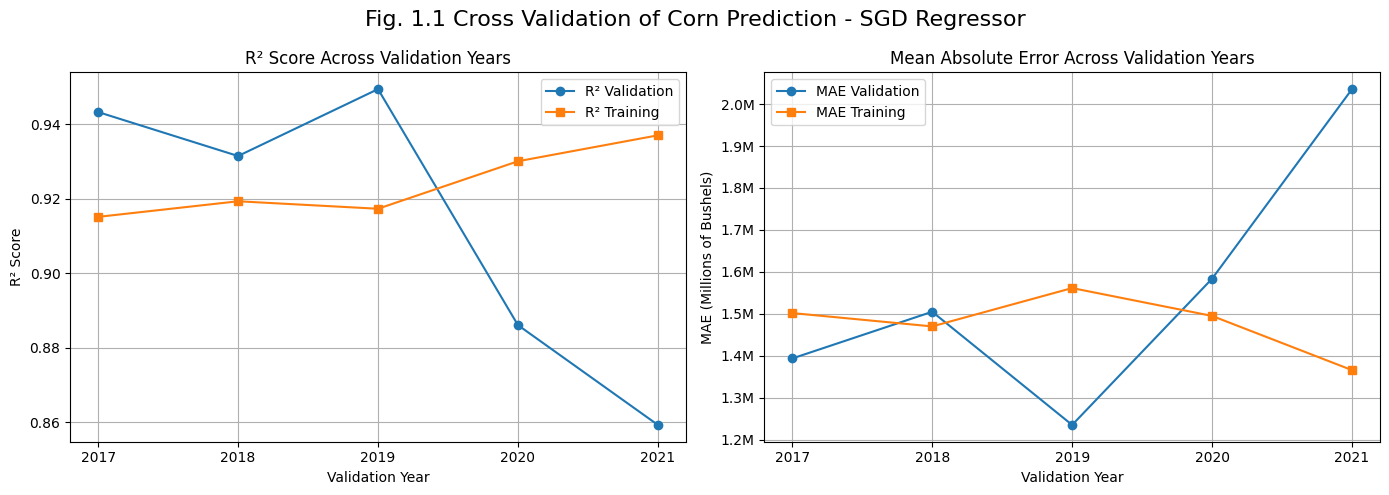

                                      Metric   Train Validation
0                               Avg R2 Score    0.92       0.91
1              Avg Mean Absolute Error (MAE)   1.48M      1.55M
2         Avg Root Mean Squared Error (RMSE)   2.20M      2.28M
3  Avg Mean Absolute Percentage Error (MAPE)  69.49%     69.58%
4                              Avg Max Error  11.50M     10.69M


In [115]:

corn_cross_val_training_result_complete_features_SGD = helper.perform_cross_validation(train_set=train_set_complete_corn, 
                                                                 target_column=corn_target, 
                                                                 scaler=standard_scaler_corn_complete,
                                                                 model=SGDRegressor(random_state=42, **best_sgd_corn['params']))
helper.plot_cross_validation_result(corn_cross_val_training_result_complete_features_SGD, title="Fig. 1.1 Cross Validation of Corn Prediction - SGD Regressor")

#### 1.1.2 Log Transformation + Standard Scaler

In [18]:
sgd_grid_search_results_corn_log_transformed = []
count = 1
for params in sgd_param_combinations:
    model = SGDRegressor(random_state=42, **params)
    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_corn_data, corn_target,
        scaler=standard_scaler_corn_complete, model=model,
        verbose=False, max_safe_exp=100
    )
    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    sgd_grid_search_results_corn_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    
    print(f"\rGrid Search Process: {count}/{len(sgd_param_combinations)}", end='', flush=True)
    count += 1
    
    
best_sgd_corn_log_transformed = max(sgd_grid_search_results_corn_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SGDRegressor Corn Prediction Grid Search Result")
print("  Best params:", best_sgd_corn_log_transformed['params'])
print("  Mean R²:", best_sgd_corn_log_transformed['mean_r2'])
print("  Mean MAE:", best_sgd_corn_log_transformed['mean_mae'])

Grid Search Process: 140/140
SGDRegressor Corn Prediction Grid Search Result
  Best params: {'penalty': 'l1', 'alpha': 0.05, 'learning_rate': 'constant', 'eta0': 0.05}
  Mean R²: 0.9107769602704643
  Mean MAE: 1490253.186567509


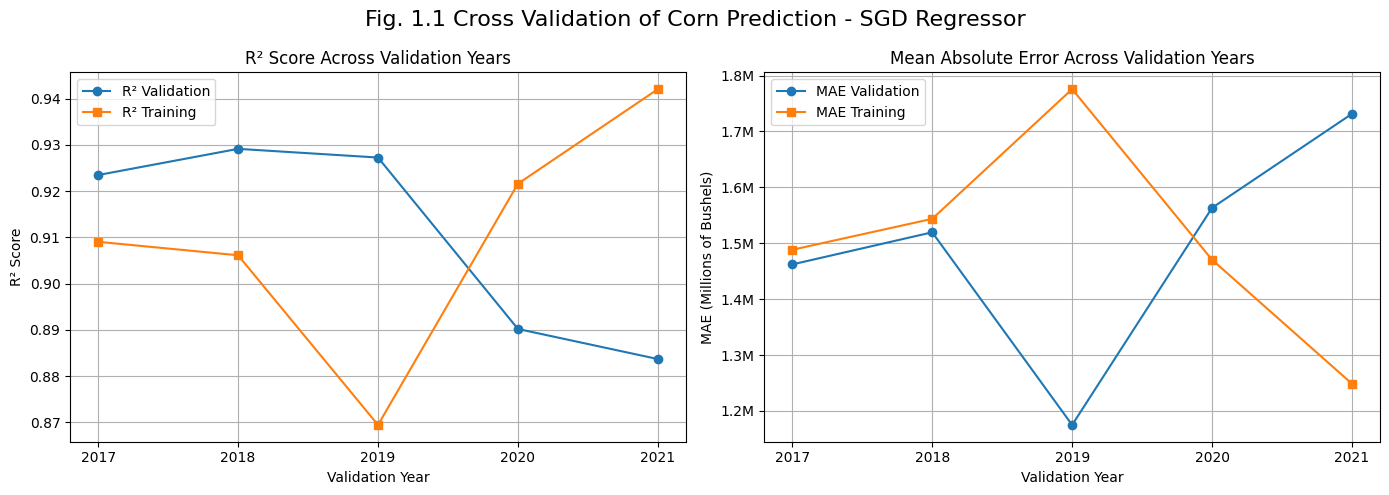

                                      Metric   Train Validation
0                               Avg R2 Score    0.91       0.91
1              Avg Mean Absolute Error (MAE)   1.51M      1.49M
2         Avg Root Mean Squared Error (RMSE)   2.38M      2.36M
3  Avg Mean Absolute Percentage Error (MAPE)  28.41%     27.77%
4                              Avg Max Error  13.02M     11.23M


In [116]:
corn_cross_val_training_result_complete_features_SGD_log_transformed = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_corn_data, 
        corn_target,
        scaler=standard_scaler_corn_complete, 
        model=SGDRegressor(random_state=42, **best_sgd_corn_log_transformed['params']),
        verbose=False, max_safe_exp=100)
helper.plot_cross_validation_result(corn_cross_val_training_result_complete_features_SGD_log_transformed, title="Fig. 1.1 Cross Validation of Corn Prediction - SGD Regressor")

### 1.2 SVR Regressor

#### 1.2.1 Standard Scaler Only

In [20]:
svr_grid_search_results_corn = []
count = 1
for params in svr_param_combinations:
    model = SVR(**params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_complete_corn,
        target_column=corn_target,
        model=model,
        scaler=standard_scaler_corn_complete,  # SVR is scale-sensitive
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    svr_grid_search_results_corn.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(svr_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_svr_param_corn = max(svr_grid_search_results_corn, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SVR Corn Prediction Grid Search Result")
print("  Best params:", best_svr_param_corn['params'])
print("  Mean R²:", best_svr_param_corn['mean_r2'])
print("  Mean MAE:", best_svr_param_corn['mean_mae'])


Grid Search Process: 144/144
SVR Corn Prediction Grid Search Result
  Best params: {'kernel': 'linear', 'C': 500000, 'epsilon': 50}
  Mean R²: 0.9121659717867354
  Mean MAE: 1540031.8625314839


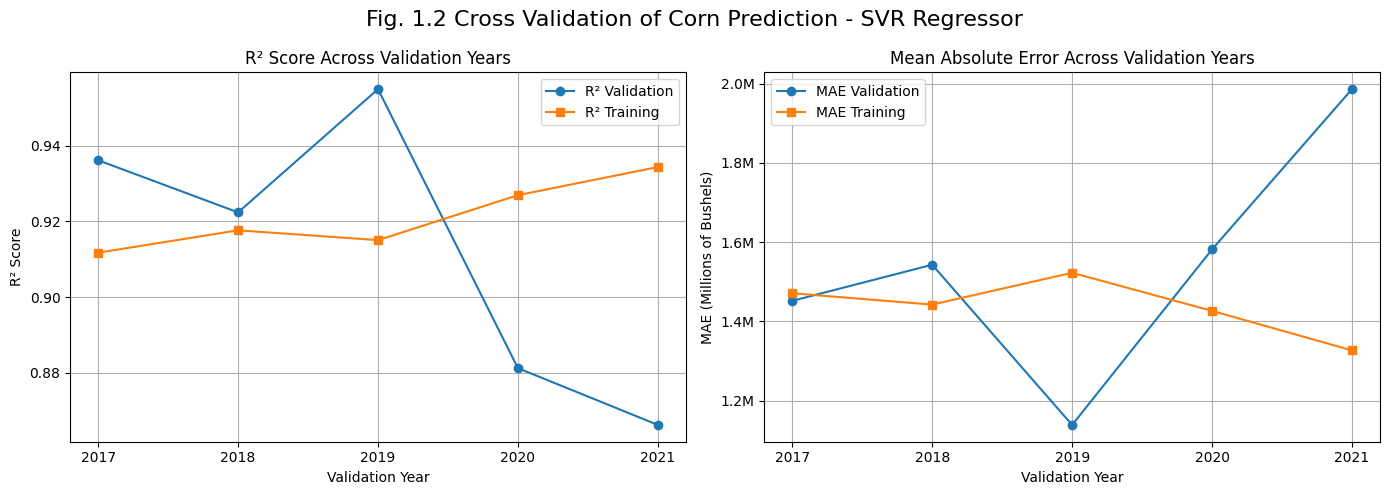

                                      Metric   Train Validation
0                               Avg R2 Score    0.92       0.91
1              Avg Mean Absolute Error (MAE)   1.44M      1.54M
2         Avg Root Mean Squared Error (RMSE)   2.24M      2.31M
3  Avg Mean Absolute Percentage Error (MAPE)  48.62%     55.45%
4                              Avg Max Error  12.47M     10.98M


In [117]:

corn_cross_val_training_result_complete_features_SVR = helper.perform_cross_validation(train_set=train_set_complete_corn, 
                                                                 target_column=corn_target, 
                                                                 scaler=standard_scaler_corn_complete,
                                                                 model=SVR(**best_svr_param_corn['params']))
helper.plot_cross_validation_result(corn_cross_val_training_result_complete_features_SVR, title="Fig. 1.2 Cross Validation of Corn Prediction - SVR Regressor")

#### 1.2.2 Log Transformation + Standard Scaler

In [22]:
svr_grid_search_results_corn_log_transformed = []
count = 1
for params in svr_param_combinations_log_transformed:
    
    model = SVR(**params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_corn_data, 
        corn_target,
        scaler=standard_scaler_corn_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    svr_grid_search_results_corn_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    
    print(f"\rGrid Search Process: {count}/{len(svr_param_combinations_log_transformed)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_svr_param_corn_log_transformed = max(svr_grid_search_results_corn_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SVR Corn Prediction Grid Search Result")
print("  Best params:", best_svr_param_corn_log_transformed['params'])
print("  Mean R²:", best_svr_param_corn_log_transformed['mean_r2'])
print("  Mean MAE:", best_svr_param_corn_log_transformed['mean_mae'])


Grid Search Process: 60/60
SVR Corn Prediction Grid Search Result
  Best params: {'kernel': 'rbf', 'C': 10, 'epsilon': 0.1, 'gamma': 'scale'}
  Mean R²: 0.9138471373777696
  Mean MAE: 1269956.7858049653


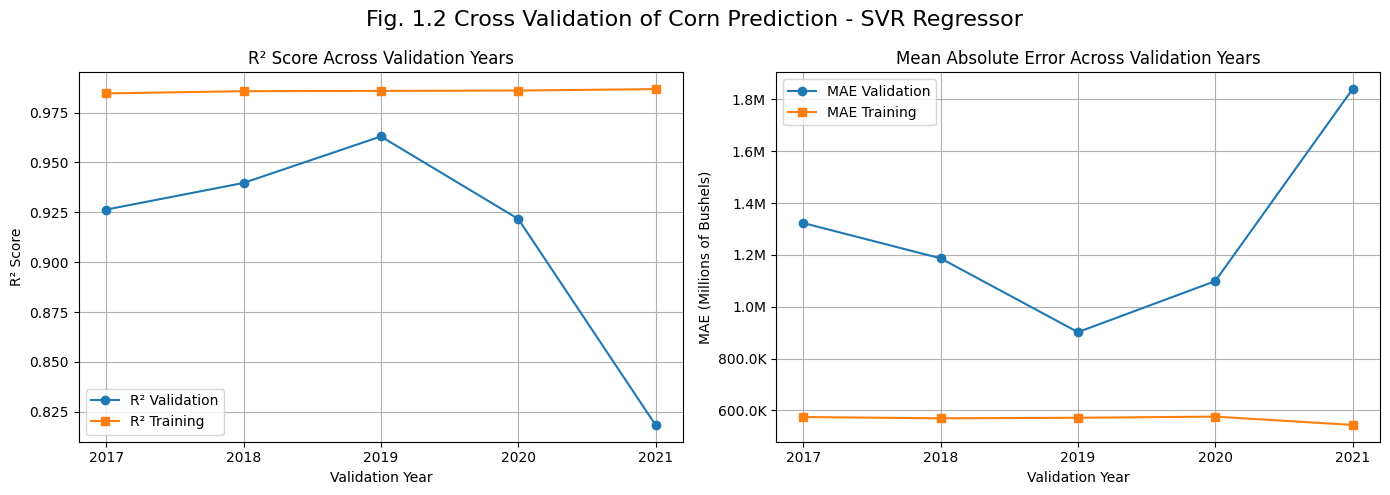

                                      Metric    Train Validation
0                               Avg R2 Score     0.99       0.91
1              Avg Mean Absolute Error (MAE)  567.13K      1.27M
2         Avg Root Mean Squared Error (RMSE)  951.31K      2.26M
3  Avg Mean Absolute Percentage Error (MAPE)    9.35%     24.30%
4                              Avg Max Error    5.19M     13.07M


In [118]:
corn_cross_val_training_result_complete_features_SVR = helper.perform_cv_with_precomputed_transforms(
    precomputed_log_transformed_corn_data, 
    corn_target,
    scaler=standard_scaler_corn_complete, 
    verbose=False, max_safe_exp=100,
    model=SVR(**best_svr_param_corn_log_transformed['params']),
     
)
helper.plot_cross_validation_result(corn_cross_val_training_result_complete_features_SVR, title="Fig. 1.2 Cross Validation of Corn Prediction - SVR Regressor")

### 1.3 RF Regressor

#### 1.3.1 Standard Scaler Only

In [24]:
rf_grid_search_results_corn = []
count = 1
for params in rf_param_combinations:
    model = RandomForestRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_complete_corn,
        target_column=corn_target,
        model=model,
        scaler=standard_scaler_corn_complete  # scaling is optional for tree-based models but kept for uniformity
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    rf_grid_search_results_corn.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(rf_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_rf_param_corn = max(rf_grid_search_results_corn, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("Random Forest Corn Prediction Grid Search Result")
print("  Best params:", best_rf_param_corn['params'])
print("  Mean R²:", best_rf_param_corn['mean_r2'])
print("  Mean MAE:", best_rf_param_corn['mean_mae'])

Grid Search Process: 324/324
Random Forest Corn Prediction Grid Search Result
  Best params: {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None}
  Mean R²: 0.941476431590349
  Mean MAE: 1107202.815002818


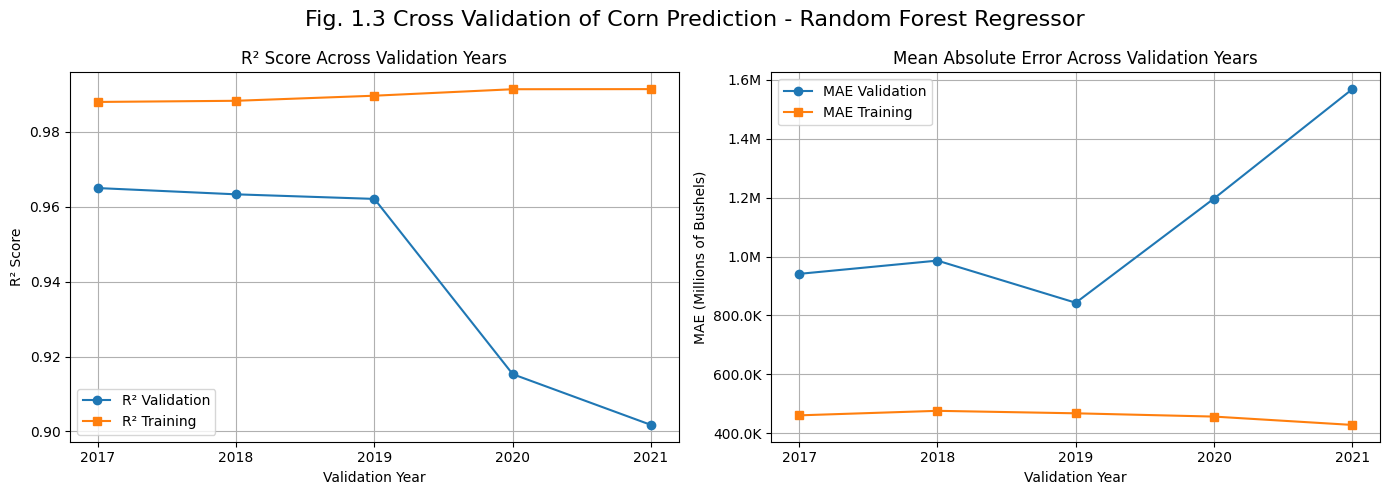

                                      Metric    Train Validation
0                               Avg R2 Score     0.99       0.94
1              Avg Mean Absolute Error (MAE)  458.04K      1.11M
2         Avg Root Mean Squared Error (RMSE)  806.28K      1.86M
3  Avg Mean Absolute Percentage Error (MAPE)   10.15%     23.49%
4                              Avg Max Error    6.94M     11.84M


In [119]:

corn_cross_val_training_result_complete_features_RF = helper.perform_cross_validation(train_set=train_set_complete_corn, 
                                                                 target_column=corn_target, 
                                                                 scaler=standard_scaler_corn_complete,
                                                                 model=RandomForestRegressor(random_state=42, **best_rf_param_corn['params']))
helper.plot_cross_validation_result(corn_cross_val_training_result_complete_features_RF, title="Fig. 1.3 Cross Validation of Corn Prediction - Random Forest Regressor")

#### 1.3.2 Log Transformation + Standard Scaler

In [26]:
rf_grid_search_results_corn_log_transformed = []
count = 1
for params in rf_param_combinations:
    model = RandomForestRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_corn_data, 
        corn_target,
        scaler=standard_scaler_corn_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    rf_grid_search_results_corn_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(rf_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_rf_param_corn_log_transformed = max(rf_grid_search_results_corn_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("Random Forest Corn Prediction Grid Search Result")
print("  Best params:", best_rf_param_corn_log_transformed['params'])
print("  Mean R²:", best_rf_param_corn_log_transformed['mean_r2'])
print("  Mean MAE:", best_rf_param_corn_log_transformed['mean_mae'])

Grid Search Process: 324/324
Random Forest Corn Prediction Grid Search Result
  Best params: {'n_estimators': 50, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None}
  Mean R²: 0.9449623696397342
  Mean MAE: 1071001.5036082081


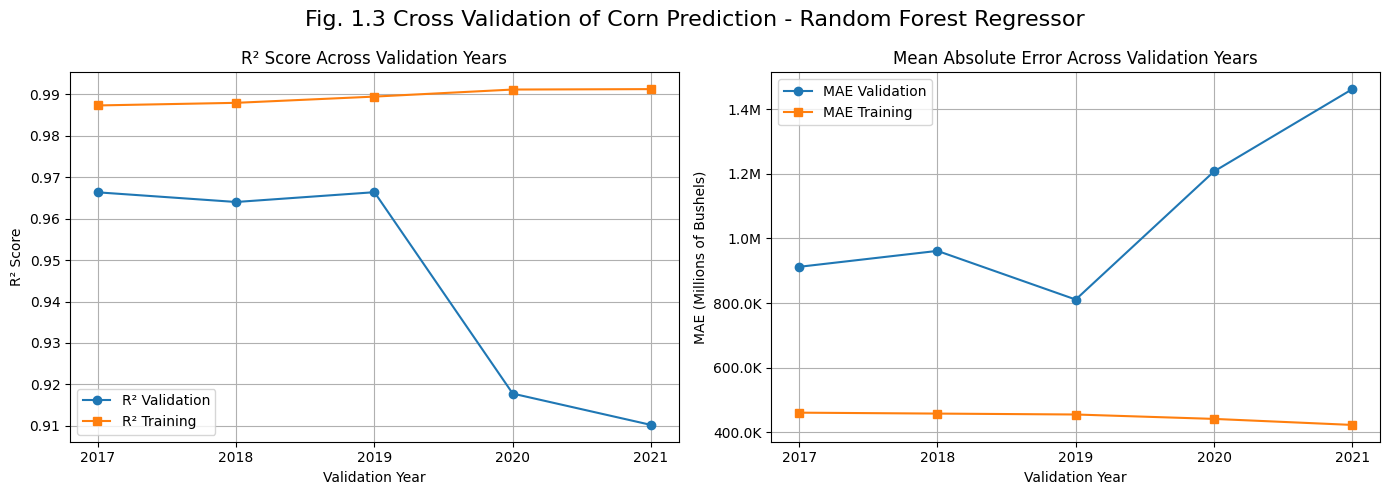

                                      Metric    Train Validation
0                               Avg R2 Score     0.99       0.94
1              Avg Mean Absolute Error (MAE)  447.65K      1.07M
2         Avg Root Mean Squared Error (RMSE)  816.71K      1.80M
3  Avg Mean Absolute Percentage Error (MAPE)    8.66%     21.67%
4                              Avg Max Error    7.08M     11.56M


In [120]:
corn_cross_val_training_result_complete_features_RF = helper.perform_cv_with_precomputed_transforms(
    precomputed_log_transformed_corn_data, 
    corn_target,
    scaler=standard_scaler_corn_complete, 
    verbose=False, 
    max_safe_exp=100,
    model=RandomForestRegressor(random_state=42, **best_rf_param_corn_log_transformed['params']),
)
helper.plot_cross_validation_result(corn_cross_val_training_result_complete_features_RF, title="Fig. 1.3 Cross Validation of Corn Prediction - Random Forest Regressor")

### 1.4 MLP Regressor

#### 1.4.1 Standard Scaler Only

In [28]:
mlp_grid_search_results_corn = []
count = 1
for params in mlp_param_combinations:
    model = MLPRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_complete_corn,
        target_column=corn_target,
        model=model,
        scaler=standard_scaler_corn_complete  # MLP is scale-sensitive
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    mlp_grid_search_results_corn.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(mlp_param_combinations)}", end='', flush=True)
    count += 1

best_mlp_param_corn = max(mlp_grid_search_results_corn, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("MLPRegressor Corn Prediction Grid Search Result")
print("  Best params:", best_mlp_param_corn['params'])
print("  Mean R²:", best_mlp_param_corn['mean_r2'])
print("  Mean MAE:", best_mlp_param_corn['mean_mae'])

Grid Search Process: 16/16
MLPRegressor Corn Prediction Grid Search Result
  Best params: {'hidden_layer_sizes': (50, 100, 50), 'activation': 'relu', 'solver': 'adam', 'alpha': 0.01, 'learning_rate': 'constant', 'learning_rate_init': 0.1, 'max_iter': 30000}
  Mean R²: 0.9221685934025139
  Mean MAE: 1453880.903152205


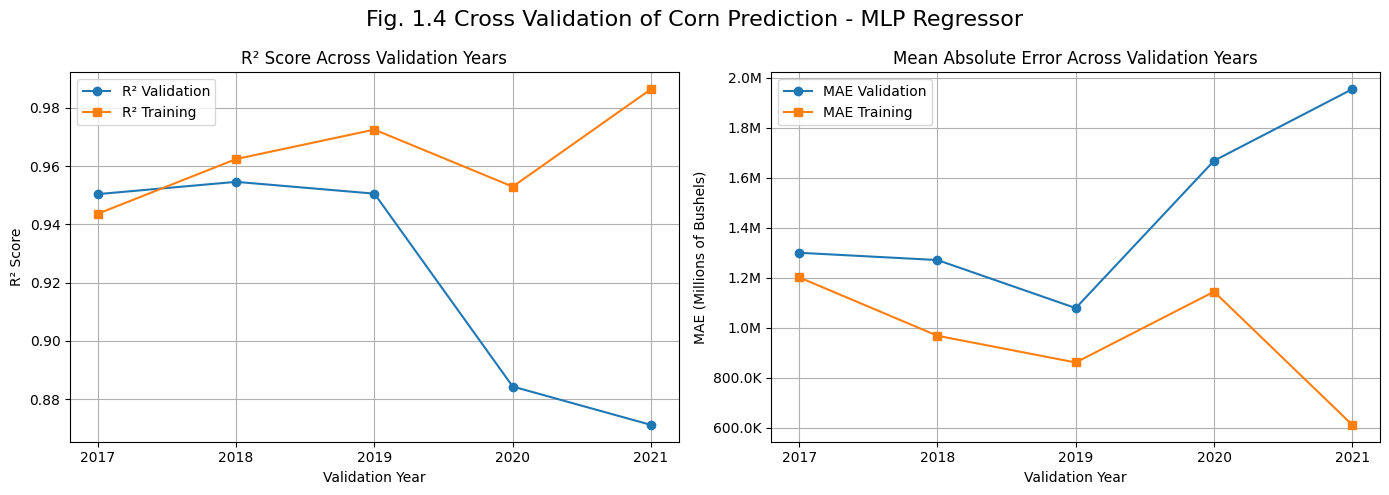

                                      Metric    Train Validation
0                               Avg R2 Score     0.96       0.92
1              Avg Mean Absolute Error (MAE)  957.05K      1.45M
2         Avg Root Mean Squared Error (RMSE)    1.49M      2.14M
3  Avg Mean Absolute Percentage Error (MAPE)   33.51%     58.02%
4                              Avg Max Error    8.98M      9.53M


In [121]:

corn_cross_val_training_result_complete_features_MLP = helper.perform_cross_validation(train_set=train_set_complete_corn, 
                                                                 target_column=corn_target, 
                                                                 scaler=standard_scaler_corn_complete,
                                                                 model=MLPRegressor(random_state=42, **best_mlp_param_corn['params']))
helper.plot_cross_validation_result(corn_cross_val_training_result_complete_features_MLP, title="Fig. 1.4 Cross Validation of Corn Prediction - MLP Regressor")

#### 1.4.2 Log Transformation + Standard Scaler

In [30]:
mlp_grid_search_results_corn_log_transformed = []
count = 1
for params in mlp_param_combinations:
    model = MLPRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_corn_data, 
        corn_target,
        scaler=standard_scaler_corn_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    mlp_grid_search_results_corn_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(mlp_param_combinations)}", end='', flush=True)
    count += 1
best_mlp_param_corn_log_transformed = max(mlp_grid_search_results_corn_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))

print()
print("MLPRegressor Corn Prediction Grid Search Result")
print("  Best params:", best_mlp_param_corn_log_transformed['params'])
print("  Mean R²:", best_mlp_param_corn_log_transformed['mean_r2'])
print("  Mean MAE:", best_mlp_param_corn_log_transformed['mean_mae'])

Grid Search Process: 16/16
MLPRegressor Corn Prediction Grid Search Result
  Best params: {'hidden_layer_sizes': (50, 100, 50), 'activation': 'relu', 'solver': 'adam', 'alpha': 1, 'learning_rate': 'constant', 'learning_rate_init': 0.1, 'max_iter': 30000}
  Mean R²: 0.9192217860346075
  Mean MAE: 1377762.4568432553


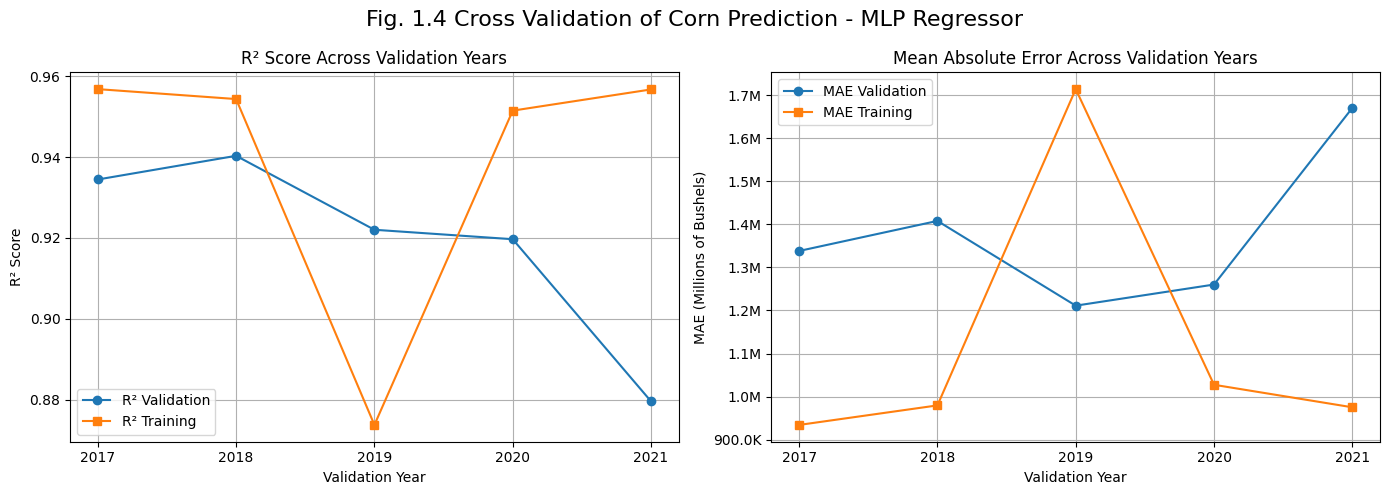

                                      Metric   Train Validation
0                               Avg R2 Score    0.94       0.92
1              Avg Mean Absolute Error (MAE)   1.13M      1.38M
2         Avg Root Mean Squared Error (RMSE)   1.93M      2.24M
3  Avg Mean Absolute Percentage Error (MAPE)  18.11%     27.18%
4                              Avg Max Error  13.51M     12.32M


In [122]:

corn_cross_val_training_result_complete_features_MLP = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_corn_data, 
        corn_target,
        scaler=standard_scaler_corn_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=MLPRegressor(random_state=42, **best_mlp_param_corn_log_transformed['params'])
)
helper.plot_cross_validation_result(corn_cross_val_training_result_complete_features_MLP, title="Fig. 1.4 Cross Validation of Corn Prediction - MLP Regressor")

### 1.5 HGBoost Regressor

#### 1.5.1 Standard Scaler Only

In [96]:
hgb_grid_search_results_corn = []
count = 1
for params in hgb_param_combinations:
    model = HistGradientBoostingRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_complete_corn,
        target_column=corn_target,
        model=model,
        scaler=standard_scaler_corn_complete
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    hgb_grid_search_results_corn.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(hgb_param_combinations)}", end='', flush=True)
    count += 1

best_hgb_param_corn = max(hgb_grid_search_results_corn, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("HGBoost Regressor Corn Prediction Grid Search Result")
print("  Best params:", best_hgb_param_corn['params'])
print("  Mean R²:", best_hgb_param_corn['mean_r2'])
print("  Mean MAE:", best_hgb_param_corn['mean_mae'])

Grid Search Process: 360/360
HGBoost Regressor Corn Prediction Grid Search Result
  Best params: {'learning_rate': 0.05, 'max_iter': 500, 'max_depth': 5, 'l2_regularization': 10.0, 'min_samples_leaf': 20}
  Mean R²: 0.9346336068524526
  Mean MAE: 1184241.8571032207


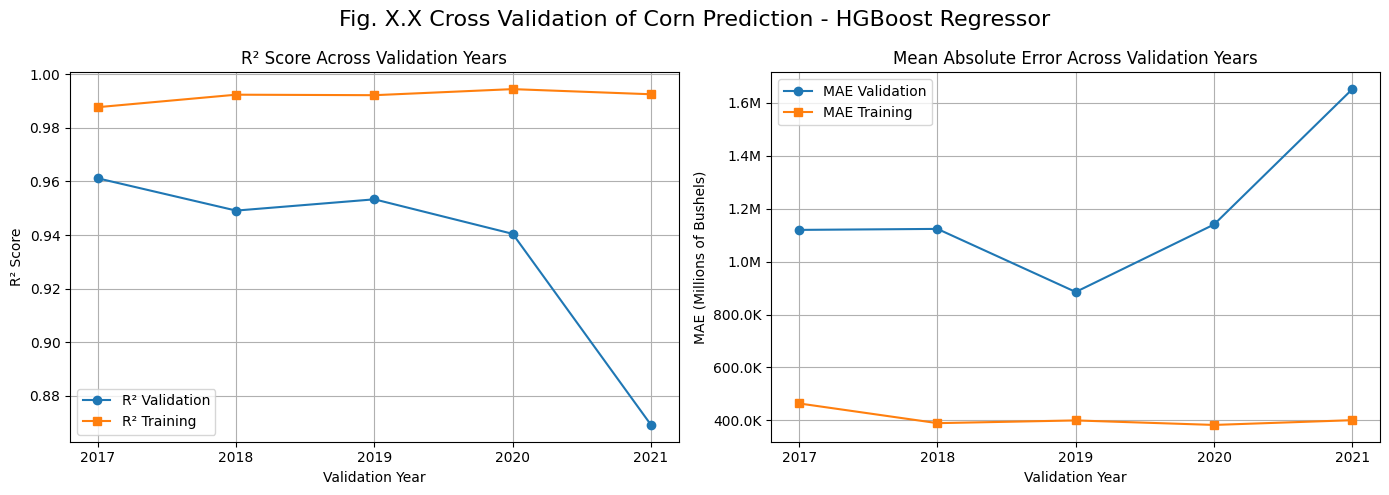

                                      Metric    Train Validation
0                               Avg R2 Score     0.99       0.93
1              Avg Mean Absolute Error (MAE)  407.41K      1.18M
2         Avg Root Mean Squared Error (RMSE)  716.17K      1.98M
3  Avg Mean Absolute Percentage Error (MAPE)   16.46%     39.98%
4                              Avg Max Error    7.09M     12.43M


In [123]:

corn_cross_val_training_result_complete_features_hgb = helper.perform_cross_validation(train_set=train_set_complete_corn, 
                                                                 target_column=corn_target, 
                                                                 scaler=standard_scaler_corn_complete,
                                                                 model=HistGradientBoostingRegressor(random_state=42, **best_hgb_param_corn['params']))
helper.plot_cross_validation_result(corn_cross_val_training_result_complete_features_hgb, title="Fig. X.X Cross Validation of Corn Prediction - HGBoost Regressor")

#### 1.5.2 Log Transformation + Standard Scaler

In [98]:
hgb_grid_search_results_corn_log_transformed = []
count = 1
for params in hgb_param_combinations:
    model = HistGradientBoostingRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_corn_data, 
        corn_target,
        scaler=standard_scaler_corn_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    hgb_grid_search_results_corn_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(hgb_param_combinations)}", end='', flush=True)
    count += 1

best_hgb_param_corn_log_transformed = max(hgb_grid_search_results_corn_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("HGBoost Regressor Corn Prediction Grid Search Result")
print("  Best params:", best_hgb_param_corn_log_transformed['params'])
print("  Mean R²:", best_hgb_param_corn_log_transformed['mean_r2'])
print("  Mean MAE:", best_hgb_param_corn_log_transformed['mean_mae'])

Grid Search Process: 360/360
HGBoost Regressor Corn Prediction Grid Search Result
  Best params: {'learning_rate': 0.1, 'max_iter': 100, 'max_depth': 10, 'l2_regularization': 0.1, 'min_samples_leaf': 20}
  Mean R²: 0.9309212916382984
  Mean MAE: 1135447.0063671232


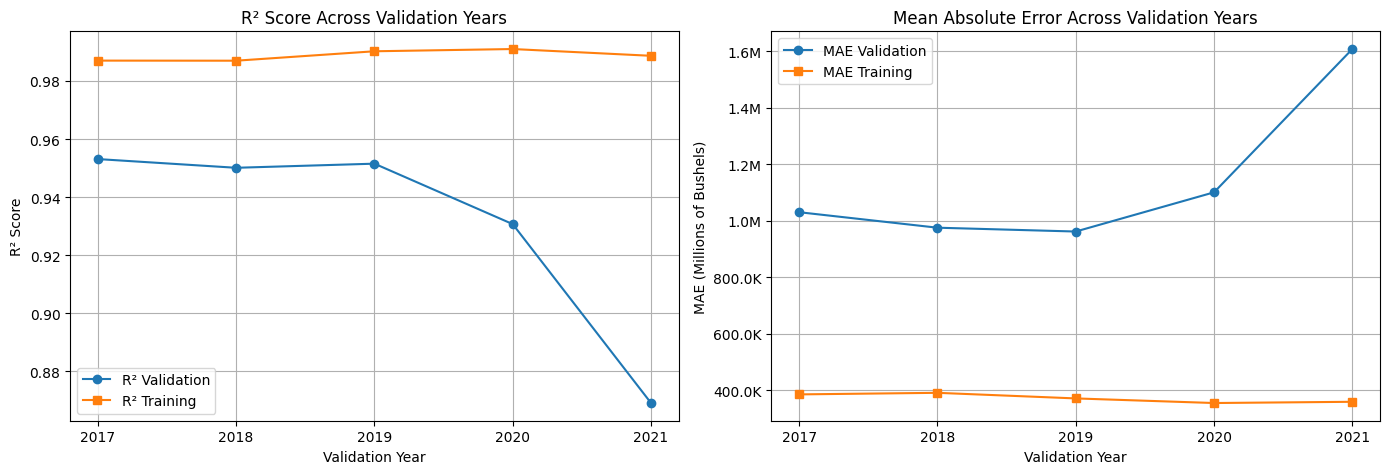

                                      Metric    Train Validation
0                               Avg R2 Score     0.99       0.93
1              Avg Mean Absolute Error (MAE)  371.66K      1.14M
2         Avg Root Mean Squared Error (RMSE)  842.95K      2.04M
3  Avg Mean Absolute Percentage Error (MAPE)    5.97%     20.99%
4                              Avg Max Error    8.52M     13.44M


In [156]:
corn_cross_val_training_result_complete_features_hgb_log_transformed =  helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_corn_data, 
        corn_target,
        scaler=standard_scaler_corn_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=HistGradientBoostingRegressor(random_state=42, **best_hgb_param_corn_log_transformed['params'])
)
helper.plot_cross_validation_result(corn_cross_val_training_result_complete_features_hgb_log_transformed)

## 2 Soybeans Prediction

In [32]:
soybeans_target = 'PRODUCTION, MEASURED IN BU'

In [33]:
merged_soybeans_dataset = pd.read_csv(merged_weather_and_soybeans_production_data_dir)

complete_soybeans_dataset = merged_soybeans_dataset.drop(["Unnamed: 0", "State", "County", "FIPS Code"], axis=1)
complete_soybeans_dataset

,Avg Temperature (C),Max Temperature (C),Min Temperature (C),Heat_Stress_Day,Cold_Stress_Day,Precipitation (mm),Vapor Pressure Deficit (kPa),Drought_Stress_Day,Wet_Day,Heavy_Rain_Day,Solar Radiation (MJ m**-2 day**-1),Low_Light_Day,Relative Humidity (%),Wind Speed (m s**-1),Year,"PRODUCTION, MEASURED IN BU",harvested_area
0,17.778272,35.917027,-11.813784,5.567568,127.891892,1652.416135,0.696802,0.000000,104.648649,18.864865,126087.217712,5.918919,71.964857,5.487101,2017,10040000.0,186964.618250
1,18.603199,35.795500,-8.312000,3.700000,108.800000,1844.636750,0.683657,0.000000,113.000000,23.200000,122775.899299,11.200000,73.309178,5.077573,2017,3490000.0,61443.661972
2,18.669693,35.024000,-8.272000,1.200000,100.933333,1869.680867,0.641058,0.000000,112.333333,25.666667,127958.411779,9.200000,74.422411,5.543904,2017,8647000.0,168886.718750
3,16.135538,35.586250,-11.329375,3.375000,149.125000,1388.596562,0.616330,0.000000,104.312500,13.937500,130721.404219,7.687500,72.694829,4.815941,2017,6583000.0,120127.737226
4,16.813532,35.128667,-14.166000,2.666667,143.066667,1579.031467,0.613917,0.000000,103.266667,20.800000,127231.905283,10.933333,73.269534,2.827332,2017,745000.0,18908.629442
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,18.416672,41.462083,-13.213333,67.250000,131.916667,679.067958,1.068879,23.041667,50.250000,7.958333,148098.711053,18.625000,61.609943,3.771743,2022,63000.0,3750.000000
1076,18.263845,41.040800,-13.519200,64.800000,133.960000,685.627920,1.004137,15.480000,55.960000,8.240000,145956.933936,18.640000,63.513699,3.627239,2022,110000.0,9166.666667
1077,14.646052,42.690000,-19.465000,60.150000,184.750000,185.716650,1.222846,34.700000,30.400000,0.550000,165870.188381,12.100000,48.896740,4.936296,2022,139000.0,3492.462312
1078,21.463896,39.329394,-8.130303,66.939394,88.181818,520.929485,0.877018,0.000000,53.181818,4.878788,148370.152427,18.606061,71.104193,5.979935,2022,34500.0,2379.310345


In [34]:
train_set_complete_soybeans, test_set_complete_soybeans = helper.split_dataset_by_year(complete_soybeans_dataset, 2022)
standard_scaler_soybeans_complete = StandardScaler()

In [35]:
X_test_complete_soybeans = test_set_complete_soybeans.drop(columns=[soybeans_target])
y_test_complete_soybeans = test_set_complete_soybeans[soybeans_target]

In [112]:
precomputed_log_transformed_soybeans_data = helper.precompute_transformations_by_fold(
        train_set_complete_soybeans, soybeans_target,
        feature_skew_threshold=1.0,
        target_skew_threshold=1.0,
        verbose=False
)

In [113]:
precomputed_log_transformed_soybeans_data

{np.int64(2017): {'train_data':      Avg Temperature (C)  Max Temperature (C)  Min Temperature (C)  \
  188            17.171745            35.971622           -15.372162   
  189            17.938471            37.177000           -13.421500   
  190            17.842027            36.042667           -13.774667   
  191            15.507971            35.909375           -15.628750   
  192            16.029138            37.036000           -12.922667   
  ..                   ...                  ...                  ...   
  882            17.712356            36.598400           -20.934000   
  883            20.599730            35.294103           -10.865641   
  884            21.524092            33.535962            -8.735962   
  885            21.463878            36.598788           -10.026061   
  886            20.972970            35.117000           -10.243750   
  
       Heat_Stress_Day  Cold_Stress_Day  Precipitation (mm)  \
  188         2.652480       141.432432 

### 2.1 SGD Regressor

#### 2.1.1 Standard Scaler Only

In [37]:
sgd_grid_search_results_soybeans = []
count = 1
for params in sgd_param_combinations:
    model = SGDRegressor(random_state=42, **params)
    cv_result = helper.perform_cross_validation(
        train_set=train_set_complete_soybeans,
        target_column=soybeans_target,
        model=model,
        scaler=standard_scaler_soybeans_complete,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    sgd_grid_search_results_soybeans.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(sgd_param_combinations)}", end='', flush=True)
    count += 1
    
best_sgd_soybeans = max(sgd_grid_search_results_soybeans, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SGDRegressor Soybeans Prediction Grid Search Result")
print("  Best params:", best_sgd_soybeans['params'])
print("  Mean R²:", best_sgd_soybeans['mean_r2'])
print("  Mean MAE:", best_sgd_soybeans['mean_mae'])

Grid Search Process: 140/140
SGDRegressor Soybeans Prediction Grid Search Result
  Best params: {'penalty': 'l2', 'alpha': 0.05, 'learning_rate': 'constant', 'eta0': 0.01}
  Mean R²: 0.8575971237703015
  Mean MAE: 819449.689569761


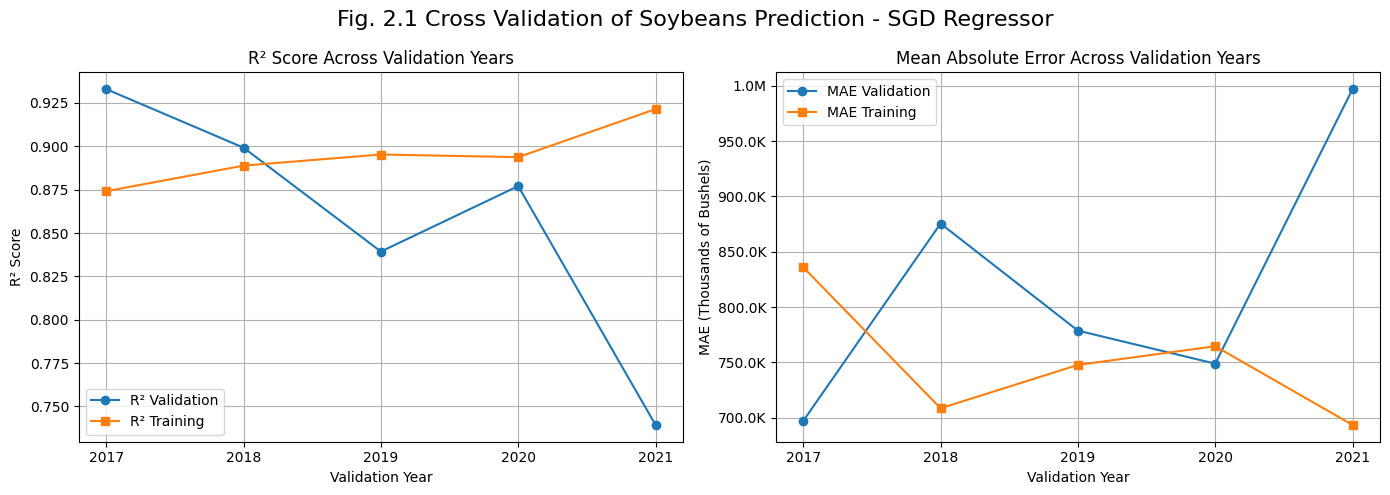

                                      Metric    Train Validation
0                               Avg R2 Score     0.89       0.86
1              Avg Mean Absolute Error (MAE)  750.07K    819.45K
2         Avg Root Mean Squared Error (RMSE)    1.02M      1.12M
3  Avg Mean Absolute Percentage Error (MAPE)   73.11%     84.53%
4                              Avg Max Error    5.06M      4.34M


In [125]:
soybeans_cross_val_training_result_complete_features_SGD = helper.perform_cross_validation(train_set=train_set_complete_soybeans, 
                                                                 target_column=soybeans_target, 
                                                                 scaler=standard_scaler_soybeans_complete,
                                                                 model=SGDRegressor(random_state=42, **best_sgd_soybeans['params'])
                                                                 )
helper.plot_cross_validation_result(soybeans_cross_val_training_result_complete_features_SGD, title="Fig. 2.1 Cross Validation of Soybeans Prediction - SGD Regressor")

#### 2.1.2 Log Transformation + Standard Scaler 

In [39]:
sgd_grid_search_results_soybeans_log_transformed = []
count = 1
for params in sgd_param_combinations:
    model = SGDRegressor(random_state=42, **params)
    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_soybeans_data, soybeans_target,
        scaler=standard_scaler_soybeans_complete, model=model,
        verbose=False, max_safe_exp=100
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    sgd_grid_search_results_soybeans_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(sgd_param_combinations)}", end='', flush=True)
    count += 1
    
best_sgd_soybeans_log_transformed = max(sgd_grid_search_results_soybeans_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SGDRegressor Soybeans Prediction Grid Search Result")
print("  Best params:", best_sgd_soybeans_log_transformed['params'])
print("  Mean R²:", best_sgd_soybeans_log_transformed['mean_r2'])
print("  Mean MAE:", best_sgd_soybeans_log_transformed['mean_mae'])

Grid Search Process: 140/140
SGDRegressor Soybeans Prediction Grid Search Result
  Best params: {'penalty': 'l1', 'alpha': 0.05, 'learning_rate': 'constant', 'eta0': 0.001}
  Mean R²: 0.8777022206874012
  Mean MAE: 707267.3851344645


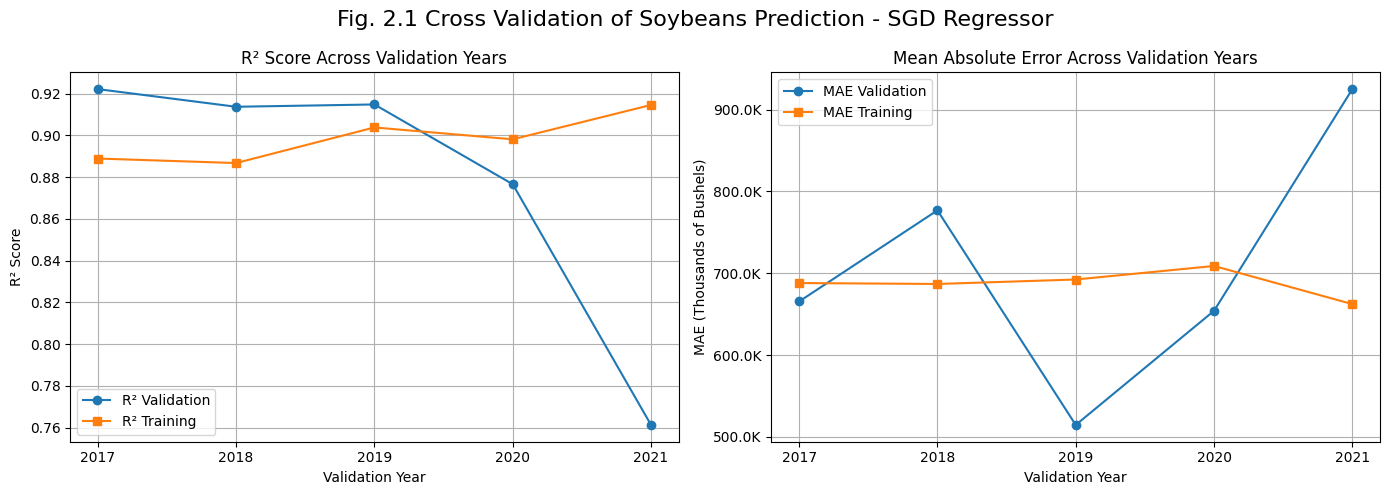

                                      Metric    Train Validation
0                               Avg R2 Score     0.90       0.88
1              Avg Mean Absolute Error (MAE)  687.74K    707.27K
2         Avg Root Mean Squared Error (RMSE)    1.00M      1.04M
3  Avg Mean Absolute Percentage Error (MAPE)   23.71%     24.08%
4                              Avg Max Error    4.46M      4.34M


In [126]:
soybeans_cross_val_training_result_complete_features_SGD_log_transformed = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_soybeans_data, 
        soybeans_target,
        scaler=standard_scaler_soybeans_complete, 
        model=SGDRegressor(random_state=42, **best_sgd_soybeans_log_transformed['params']),
        verbose=False, max_safe_exp=100)
helper.plot_cross_validation_result(soybeans_cross_val_training_result_complete_features_SGD_log_transformed, title="Fig. 2.1 Cross Validation of Soybeans Prediction - SGD Regressor")

### 2.2 SVR Regressor

#### 2.2.1 Standard Scaler Only

In [41]:
svr_grid_search_results_soybeans = []
count = 1
for params in svr_param_combinations:
    model = SVR(**params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_complete_soybeans,
        target_column=soybeans_target,
        model=model,
        scaler=standard_scaler_soybeans_complete,  # SVR is scale-sensitive
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    svr_grid_search_results_soybeans.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    
    print(f"\rGrid Search Process: {count}/{len(svr_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_svr_param_soybeans = max(svr_grid_search_results_soybeans, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SVR Soybeans Prediction Grid Search Result")
print("  Best params:", best_svr_param_soybeans['params'])
print("  Mean R²:", best_svr_param_soybeans['mean_r2'])
print("  Mean MAE:", best_svr_param_soybeans['mean_mae'])


Grid Search Process: 144/144
SVR Soybeans Prediction Grid Search Result
  Best params: {'kernel': 'linear', 'C': 50000, 'epsilon': 0.1}
  Mean R²: 0.8395477413136128
  Mean MAE: 873291.2187621703


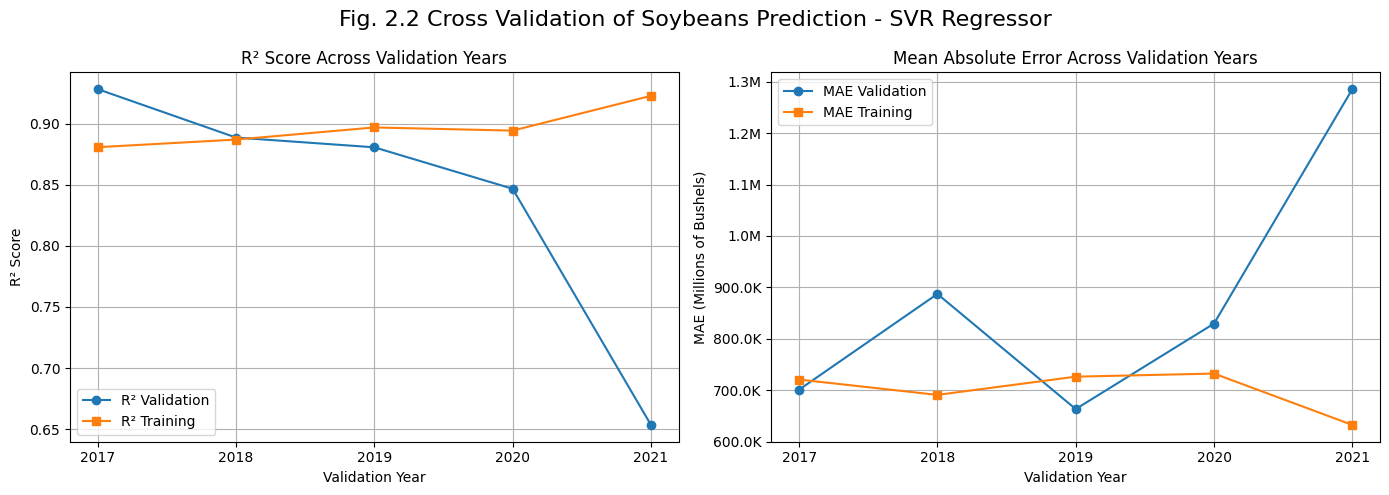

                                      Metric    Train Validation
0                               Avg R2 Score     0.90       0.84
1              Avg Mean Absolute Error (MAE)  700.49K    873.29K
2         Avg Root Mean Squared Error (RMSE)    1.01M      1.17M
3  Avg Mean Absolute Percentage Error (MAPE)   52.38%     94.60%
4                              Avg Max Error    5.03M      4.59M


In [127]:
soybeans_cross_val_training_result_complete_features_SVR = helper.perform_cross_validation(train_set=train_set_complete_soybeans, 
                                                                 target_column=soybeans_target, 
                                                                 scaler=standard_scaler_soybeans_complete,
                                                                 model=SVR(**best_svr_param_soybeans['params'])
                                                                 )
helper.plot_cross_validation_result(soybeans_cross_val_training_result_complete_features_SVR, title="Fig. 2.2 Cross Validation of Soybeans Prediction - SVR Regressor")

#### 2.2.2 Log Transformation + Standard Scaler 

In [43]:
svr_grid_search_results_soybeans_log_transformed = []
count = 1
for params in svr_param_combinations_log_transformed:
    model = SVR(**params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_soybeans_data, 
        soybeans_target,
        scaler=standard_scaler_soybeans_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    svr_grid_search_results_soybeans_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    
    print(f"\rGrid Search Process: {count}/{len(svr_param_combinations_log_transformed)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_svr_param_soybeans_log_transformed = max(svr_grid_search_results_soybeans_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SVR Soybeans Prediction Grid Search Result")
print("  Best params:", best_svr_param_soybeans_log_transformed['params'])
print("  Mean R²:", best_svr_param_soybeans_log_transformed['mean_r2'])
print("  Mean MAE:", best_svr_param_soybeans_log_transformed['mean_mae'])


Grid Search Process: 60/60
SVR Soybeans Prediction Grid Search Result
  Best params: {'kernel': 'rbf', 'C': 5, 'epsilon': 0.1, 'gamma': 'scale'}
  Mean R²: 0.830446618409271
  Mean MAE: 744463.536139845


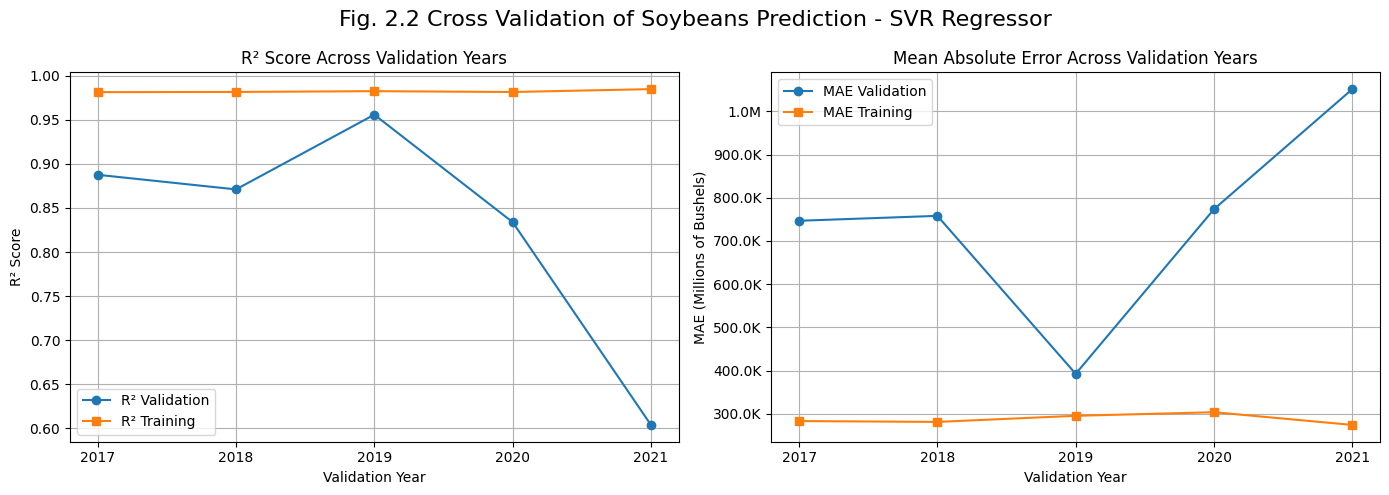

                                      Metric    Train Validation
0                               Avg R2 Score     0.98       0.83
1              Avg Mean Absolute Error (MAE)  287.68K    744.46K
2         Avg Root Mean Squared Error (RMSE)  420.58K      1.20M
3  Avg Mean Absolute Percentage Error (MAPE)    8.90%     28.43%
4                              Avg Max Error    2.35M      5.46M


In [128]:
soybeans_cross_val_training_result_complete_features_SVR_log_transformed = helper.perform_cv_with_precomputed_transforms(
    precomputed_log_transformed_soybeans_data, 
    soybeans_target,
    scaler=standard_scaler_soybeans_complete, 
    verbose=False, max_safe_exp=100,
    model=SVR(**best_svr_param_soybeans_log_transformed['params']), 
)
helper.plot_cross_validation_result(soybeans_cross_val_training_result_complete_features_SVR_log_transformed, title="Fig. 2.2 Cross Validation of Soybeans Prediction - SVR Regressor")

### 2.3 Random Forest Regressor

#### 2.3.1 Standard Scaler Only

In [45]:
rf_grid_search_results_soybeans = []
count = 1
for params in rf_param_combinations:
    model = RandomForestRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_complete_soybeans,
        target_column=soybeans_target,
        model=model,
        scaler=standard_scaler_soybeans_complete  # scaling is optional for tree-based models but kept for uniformity
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    rf_grid_search_results_soybeans.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(rf_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_rf_param_soybeans = max(rf_grid_search_results_soybeans, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("Random Forest Soybeans Prediction Grid Search Result")
print("  Best params:", best_rf_param_soybeans['params'])
print("  Mean R²:", best_rf_param_soybeans['mean_r2'])
print("  Mean MAE:", best_rf_param_soybeans['mean_mae'])

Grid Search Process: 324/324
Random Forest Soybeans Prediction Grid Search Result
  Best params: {'n_estimators': 50, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None}
  Mean R²: 0.9091861420125005
  Mean MAE: 588202.2703082946


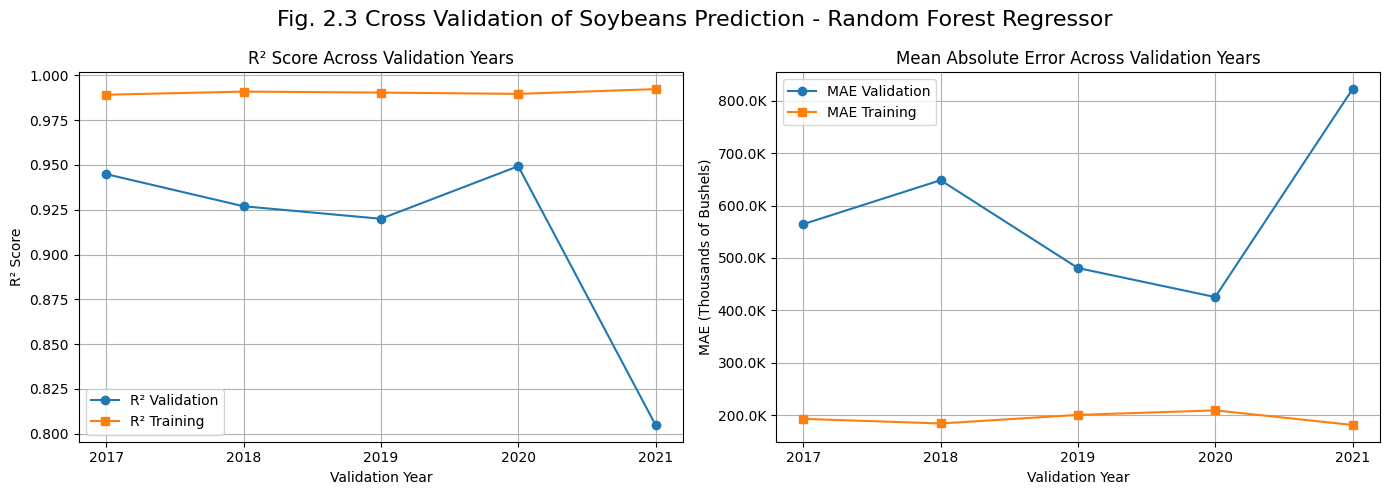

                                      Metric    Train Validation
0                               Avg R2 Score     0.99       0.91
1              Avg Mean Absolute Error (MAE)  193.96K    588.20K
2         Avg Root Mean Squared Error (RMSE)  307.60K    891.76K
3  Avg Mean Absolute Percentage Error (MAPE)    7.79%     23.90%
4                              Avg Max Error    2.49M      4.02M


In [129]:
soybeans_cross_val_training_result_complete_features_RF = helper.perform_cross_validation(train_set=train_set_complete_soybeans, 
                                                                 target_column=soybeans_target, 
                                                                 scaler=standard_scaler_soybeans_complete,
                                                                 model=RandomForestRegressor(random_state=42, **best_rf_param_soybeans['params'])
                                                                 )
helper.plot_cross_validation_result(soybeans_cross_val_training_result_complete_features_RF, title="Fig. 2.3 Cross Validation of Soybeans Prediction - Random Forest Regressor")

#### 2.3.1 Log Transformation + Standard Scaler

In [47]:
rf_grid_search_results_soybeans_log_transformed = []
count = 1
for params in rf_param_combinations:
    model = RandomForestRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_soybeans_data, 
        soybeans_target,
        scaler=standard_scaler_soybeans_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    rf_grid_search_results_soybeans_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(rf_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_rf_param_soybeans_log_transformed = max(rf_grid_search_results_soybeans_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("Random Forest Soybeans Prediction Grid Search Result")
print("  Best params:", best_rf_param_soybeans_log_transformed['params'])
print("  Mean R²:", best_rf_param_soybeans_log_transformed['mean_r2'])
print("  Mean MAE:", best_rf_param_soybeans_log_transformed['mean_mae'])

Grid Search Process: 324/324
Random Forest Soybeans Prediction Grid Search Result
  Best params: {'n_estimators': 50, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None}
  Mean R²: 0.9084709027762115
  Mean MAE: 590474.6841753117


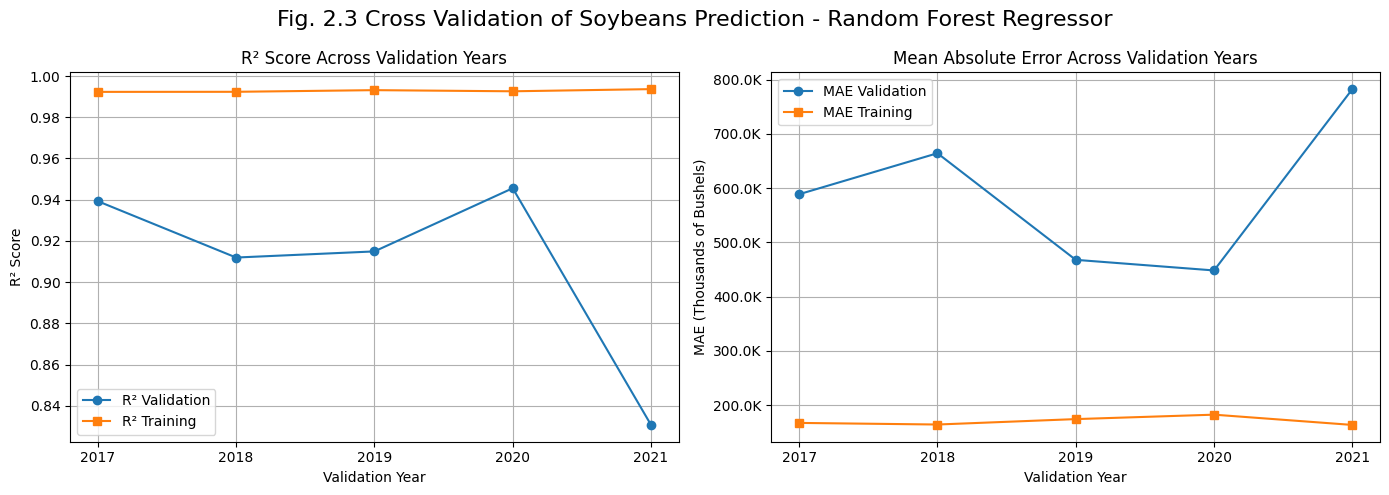

                                      Metric    Train Validation
0                               Avg R2 Score     0.99       0.91
1              Avg Mean Absolute Error (MAE)  170.28K    590.47K
2         Avg Root Mean Squared Error (RMSE)  267.44K    911.42K
3  Avg Mean Absolute Percentage Error (MAPE)    5.95%     21.25%
4                              Avg Max Error    1.86M      4.35M


In [130]:
soybeans_cross_val_training_result_complete_features_RF_log_transformed = helper.perform_cv_with_precomputed_transforms(
    precomputed_log_transformed_soybeans_data, 
    soybeans_target,
    scaler=standard_scaler_soybeans_complete, 
    verbose=False, 
    max_safe_exp=100,
    model=RandomForestRegressor(random_state=42, **best_rf_param_soybeans_log_transformed['params']),
)
helper.plot_cross_validation_result(soybeans_cross_val_training_result_complete_features_RF_log_transformed, title="Fig. 2.3 Cross Validation of Soybeans Prediction - Random Forest Regressor")

### 2.4 MLP Regressor

#### 2.4.1 Standard Scaler Only

In [49]:
mlp_grid_search_results_soybeans = []
count = 1
for params in mlp_param_combinations:
    model = MLPRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_complete_soybeans,
        target_column=soybeans_target,
        model=model,
        scaler=standard_scaler_soybeans_complete  # MLP is scale-sensitive
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    mlp_grid_search_results_soybeans.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(mlp_param_combinations)}", end='', flush=True)
    count += 1

best_mlp_param_soybeans = max(mlp_grid_search_results_soybeans, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("MLPRegressor Soybeans Prediction Grid Search Result")
print("  Best params:", best_mlp_param_soybeans['params'])
print("  Mean R²:", best_mlp_param_soybeans['mean_r2'])
print("  Mean MAE:", best_mlp_param_soybeans['mean_mae'])

Grid Search Process: 16/16
MLPRegressor Soybeans Prediction Grid Search Result
  Best params: {'hidden_layer_sizes': (50, 100, 50), 'activation': 'relu', 'solver': 'adam', 'alpha': 1, 'learning_rate': 'constant', 'learning_rate_init': 0.5, 'max_iter': 30000}
  Mean R²: 0.8811716906911752
  Mean MAE: 783091.833808779


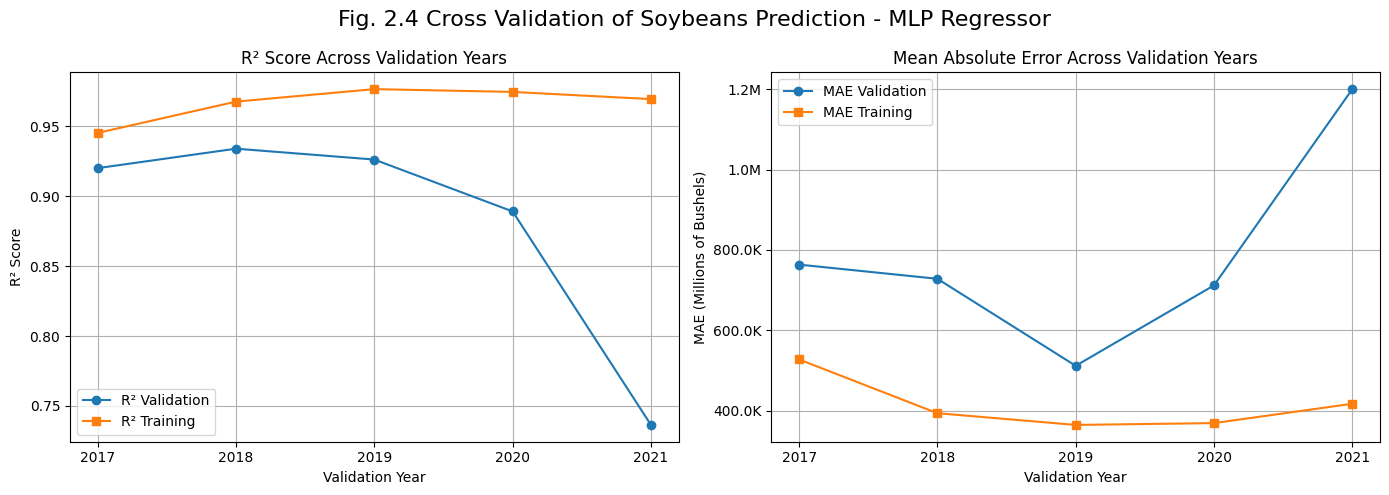

                                      Metric    Train Validation
0                               Avg R2 Score     0.97       0.88
1              Avg Mean Absolute Error (MAE)  414.67K    783.09K
2         Avg Root Mean Squared Error (RMSE)  567.56K      1.01M
3  Avg Mean Absolute Percentage Error (MAPE)   37.85%    100.39%
4                              Avg Max Error    3.20M      3.99M


In [132]:
soybeans_cross_val_training_result_complete_features_MLP = helper.perform_cross_validation(train_set=train_set_complete_soybeans, 
                                                                 target_column=soybeans_target, 
                                                                 scaler=standard_scaler_soybeans_complete,
                                                                 model=MLPRegressor(random_state=42, **best_mlp_param_soybeans['params'])
                                                                 )
helper.plot_cross_validation_result(soybeans_cross_val_training_result_complete_features_MLP, title="Fig. 2.4 Cross Validation of Soybeans Prediction - MLP Regressor")

#### 2.4.2 Log Transformation + Standard Scaler 

In [51]:
mlp_grid_search_results_soybeans_log_transformed = []
count = 1
for params in mlp_param_combinations:
    model = MLPRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_soybeans_data, 
        soybeans_target,
        scaler=standard_scaler_soybeans_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    mlp_grid_search_results_soybeans_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(mlp_param_combinations)}", end='', flush=True)
    count += 1

best_mlp_param_soybeans_log_transformed = max(mlp_grid_search_results_soybeans_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("MLPRegressor Soybeans Prediction Grid Search Result")
print("  Best params:", best_mlp_param_soybeans_log_transformed['params'])
print("  Mean R²:", best_mlp_param_soybeans_log_transformed['mean_r2'])
print("  Mean MAE:", best_mlp_param_soybeans_log_transformed['mean_mae'])

Grid Search Process: 16/16
MLPRegressor Soybeans Prediction Grid Search Result
  Best params: {'hidden_layer_sizes': (50, 100, 50), 'activation': 'relu', 'solver': 'adam', 'alpha': 5, 'learning_rate': 'constant', 'learning_rate_init': 0.01, 'max_iter': 30000}
  Mean R²: 0.9134699446114796
  Mean MAE: 591823.6967405628


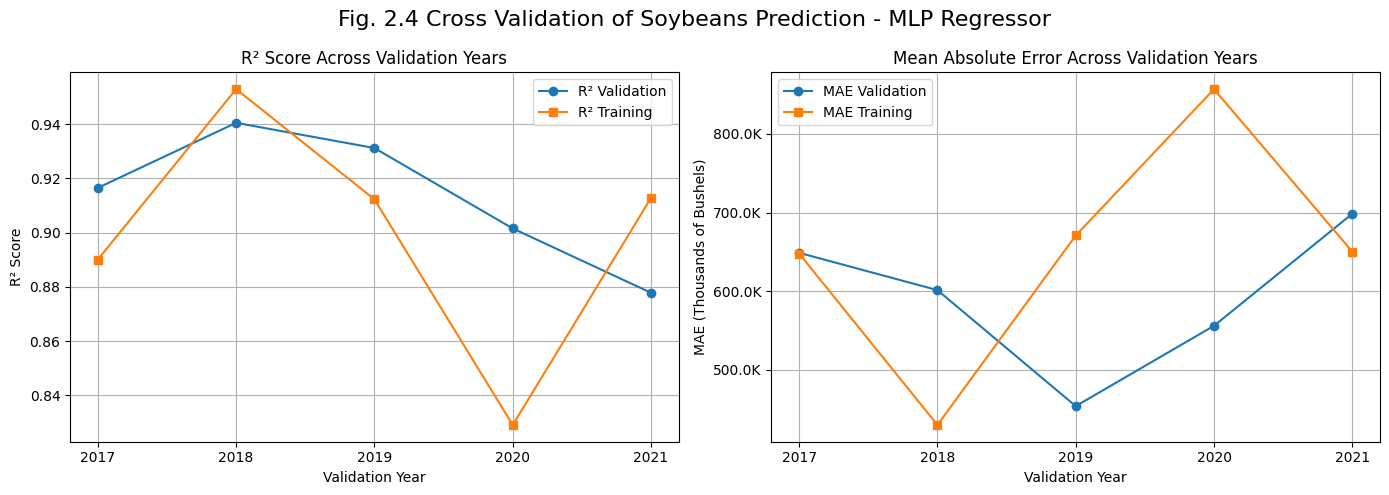

                                      Metric    Train Validation
0                               Avg R2 Score     0.90       0.91
1              Avg Mean Absolute Error (MAE)  651.23K    591.82K
2         Avg Root Mean Squared Error (RMSE)  985.97K    897.38K
3  Avg Mean Absolute Percentage Error (MAPE)   19.53%     21.97%
4                              Avg Max Error    5.96M      3.99M


In [133]:
soybeans_cross_val_training_result_complete_features_MLP_log_transformed = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_soybeans_data, 
        soybeans_target,
        scaler=standard_scaler_soybeans_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=MLPRegressor(random_state=42, **best_mlp_param_soybeans_log_transformed['params'])
)
helper.plot_cross_validation_result(soybeans_cross_val_training_result_complete_features_MLP_log_transformed, title="Fig. 2.4 Cross Validation of Soybeans Prediction - MLP Regressor")

### 2.5 HGBoost Regressor

#### 2.5.1 Standard Scaler Only

In [100]:
hgb_grid_search_results_soybeans = []
count = 1
for params in hgb_param_combinations:
    model = HistGradientBoostingRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_complete_soybeans,
        target_column=soybeans_target,
        model=model,
        scaler=standard_scaler_soybeans_complete
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    hgb_grid_search_results_soybeans.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(hgb_param_combinations)}", end='', flush=True)
    count += 1

best_hgb_param_soybeans = max(hgb_grid_search_results_soybeans, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("HGBoost Regressor Soybeans Prediction Grid Search Result")
print("  Best params:", best_hgb_param_soybeans['params'])
print("  Mean R²:", best_hgb_param_soybeans['mean_r2'])
print("  Mean MAE:", best_hgb_param_soybeans['mean_mae'])

Grid Search Process: 360/360
HGBoost Regressor Soybeans Prediction Grid Search Result
  Best params: {'learning_rate': 0.05, 'max_iter': 5000, 'max_depth': 10, 'l2_regularization': 0.1, 'min_samples_leaf': 20}
  Mean R²: 0.9151235917823307
  Mean MAE: 581178.779007733


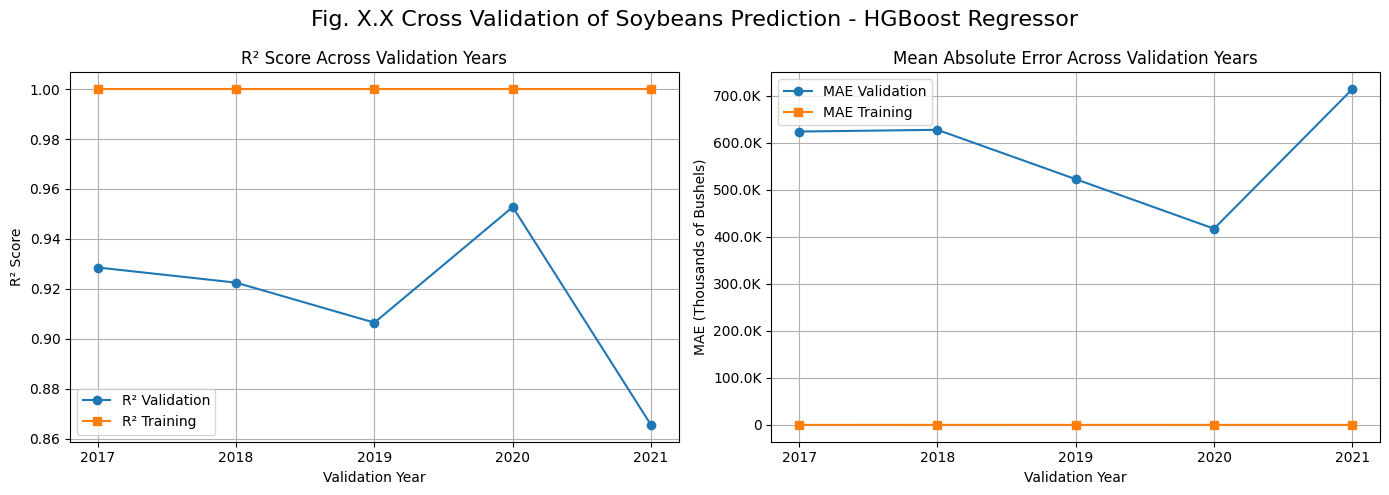

                                      Metric  Train Validation
0                               Avg R2 Score   1.00       0.92
1              Avg Mean Absolute Error (MAE)     59    581.18K
2         Avg Root Mean Squared Error (RMSE)    138    885.61K
3  Avg Mean Absolute Percentage Error (MAPE)  0.01%     33.81%
4                              Avg Max Error  1.55K      4.43M


In [134]:

soybeans_cross_val_training_result_complete_features_hgb = helper.perform_cross_validation(train_set=train_set_complete_soybeans, 
                                                                 target_column=soybeans_target, 
                                                                 scaler=standard_scaler_soybeans_complete,
                                                                 model=HistGradientBoostingRegressor(random_state=42, **best_hgb_param_soybeans['params']))
helper.plot_cross_validation_result(soybeans_cross_val_training_result_complete_features_hgb, title="Fig. X.X Cross Validation of Soybeans Prediction - HGBoost Regressor")

#### 2.5.2 Log Transformation + Standard Scaler

In [102]:
hgb_grid_search_results_soybeans_log_transformed = []
count = 1
for params in hgb_param_combinations:
    model = HistGradientBoostingRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_soybeans_data, 
        soybeans_target,
        scaler=standard_scaler_soybeans_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    hgb_grid_search_results_soybeans_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(hgb_param_combinations)}", end='', flush=True)
    count += 1

best_hgb_param_soybeans_log_transformed = max(hgb_grid_search_results_soybeans_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("HGBoost Regressor Soybeans Prediction Grid Search Result")
print("  Best params:", best_hgb_param_soybeans_log_transformed['params'])
print("  Mean R²:", best_hgb_param_soybeans_log_transformed['mean_r2'])
print("  Mean MAE:", best_hgb_param_soybeans_log_transformed['mean_mae'])

Grid Search Process: 360/360
HGBoost Regressor Soybeans Prediction Grid Search Result
  Best params: {'learning_rate': 0.01, 'max_iter': 1000, 'max_depth': 5, 'l2_regularization': 0.5, 'min_samples_leaf': 20}
  Mean R²: 0.9128525591433775
  Mean MAE: 562615.7738250887


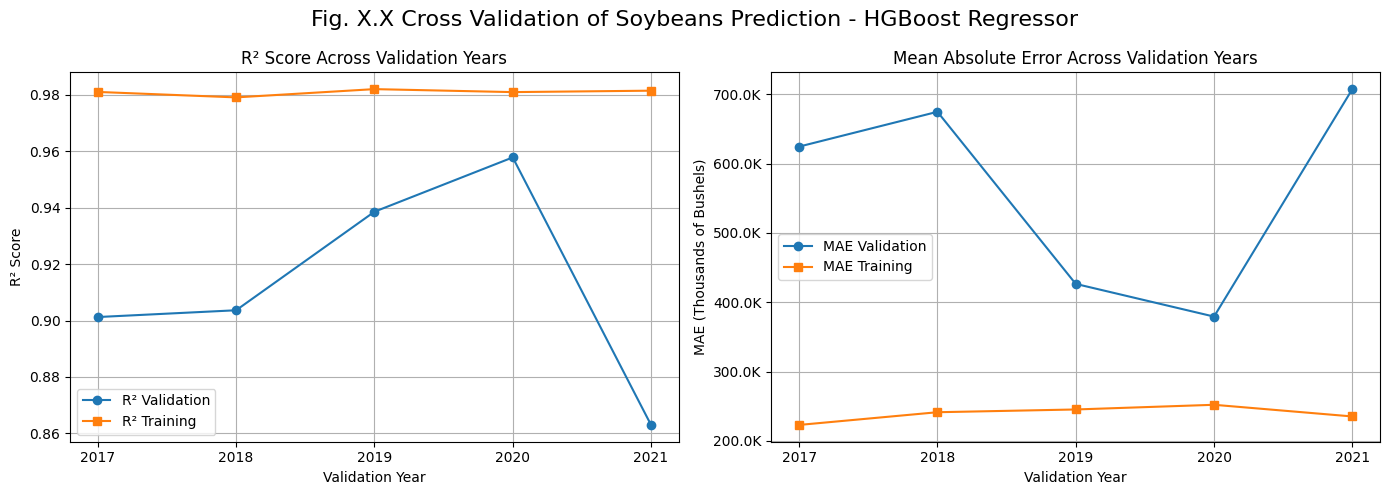

                                      Metric    Train Validation
0                               Avg R2 Score     0.98       0.91
1              Avg Mean Absolute Error (MAE)  239.44K    562.62K
2         Avg Root Mean Squared Error (RMSE)  436.04K    906.51K
3  Avg Mean Absolute Percentage Error (MAPE)    7.95%     20.00%
4                              Avg Max Error    4.65M      4.73M


In [135]:

soybeans_cross_val_training_result_complete_features_hgb_log_transformed =  helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_soybeans_data, 
        soybeans_target,
        scaler=standard_scaler_soybeans_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=HistGradientBoostingRegressor(random_state=42, **best_hgb_param_soybeans_log_transformed['params'])
)
helper.plot_cross_validation_result(soybeans_cross_val_training_result_complete_features_hgb_log_transformed, title="Fig. X.X Cross Validation of Soybeans Prediction - HGBoost Regressor")

## 3. Cotton Prediction

In [53]:
cotton_target = 'PRODUCTION, MEASURED IN 480 LB BALES'

In [54]:
merged_cotton_dataset = pd.read_csv(merged_weather_and_cotton_production_data_dir)

complete_cotton_dataset = merged_cotton_dataset.drop(["Unnamed: 0", "State", "County", "FIPS Code"], axis=1)
complete_cotton_dataset

,Avg Temperature (C),Max Temperature (C),Min Temperature (C),Heat_Stress_Day,Cold_Stress_Day,Precipitation (mm),Vapor Pressure Deficit (kPa),Drought_Stress_Day,Wet_Day,Heavy_Rain_Day,Solar Radiation (MJ m**-2 day**-1),Low_Light_Day,Relative Humidity (%),Wind Speed (m s**-1),Year,"PRODUCTION, MEASURED IN 480 LB BALES",harvested_area
0,18.603199,35.795500,-8.312000,3.700000,108.800000,1844.636750,0.683657,0.000000,113.000000,23.200000,122775.899299,11.200000,73.309178,5.077573,2017,55700.0,49.161518
1,18.669693,35.024000,-8.272000,1.200000,100.933333,1869.680867,0.641058,0.000000,112.333333,25.666667,127958.411779,9.200000,74.422411,5.543904,2017,34400.0,34.572864
2,16.135538,35.586250,-11.329375,3.375000,149.125000,1388.596562,0.616330,0.000000,104.312500,13.937500,130721.404219,7.687500,72.694829,4.815941,2017,85400.0,63.731343
3,16.506291,35.524375,-13.352500,2.312500,141.375000,1640.139375,0.606205,0.000000,103.437500,18.312500,127721.685319,11.500000,73.549795,5.196781,2017,163000.0,138.723404
4,17.549455,34.651818,-13.142273,0.636364,126.045455,1664.078455,0.670069,0.000000,110.954545,19.590909,127458.858630,11.181818,71.806139,5.111983,2017,46400.0,40.630473
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
665,18.380986,44.743077,-12.756923,97.730769,146.730769,408.647808,1.400717,59.923077,42.153846,3.115385,162556.047810,16.269231,52.384605,4.350502,2022,21300.0,24.796275
666,22.700379,38.012500,-8.792500,42.083333,59.166667,499.278667,0.813195,0.000000,45.916667,4.750000,148111.652333,18.000000,74.969521,6.951762,2022,101100.0,139.640884
667,20.250513,41.017857,-10.844286,78.023810,103.357143,553.008690,1.105926,10.095238,46.571429,6.523810,153875.616961,16.476190,63.261735,3.714269,2022,10500.0,24.193548
668,16.195158,40.266875,-15.552500,55.875000,170.812500,188.818000,1.350214,54.375000,30.875000,0.437500,176941.193213,12.687500,46.753596,4.302007,2022,22000.0,52.884615


In [55]:
train_set_complete_cotton, test_set_complete_cotton = helper.split_dataset_by_year(complete_cotton_dataset, 2022)
standard_scaler_cotton_complete = StandardScaler()

In [56]:
X_test_complete_cotton = test_set_complete_cotton.drop(columns=[cotton_target])
y_test_complete_cotton = test_set_complete_cotton[cotton_target]

In [57]:
precomputed_log_transformed_cotton_data = helper.precompute_transformations_by_fold(
        train_set_complete_cotton, cotton_target,
        feature_skew_threshold=1.0,
        target_skew_threshold=1.0,
        verbose=False
)

### 3.1 SGD Regressor

#### 3.1.1 Standard Scaler Only

In [58]:
sgd_grid_search_results_cotton = []
count = 1
for params in sgd_param_combinations:
    model = SGDRegressor(random_state=42, **params)
    cv_result = helper.perform_cross_validation(
        train_set=train_set_complete_cotton,
        target_column=cotton_target,
        model=model,
        scaler=standard_scaler_cotton_complete,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    sgd_grid_search_results_cotton.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(sgd_param_combinations)}", end='', flush=True)
    count += 1
    
best_sgd_cotton = max(sgd_grid_search_results_cotton, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SGDRegressor Cotton Prediction Grid Search Result")
print("  Best params:", best_sgd_cotton['params'])
print("  Mean R²:", best_sgd_cotton['mean_r2'])
print("  Mean MAE:", best_sgd_cotton['mean_mae'])

Grid Search Process: 140/140
SGDRegressor Cotton Prediction Grid Search Result
  Best params: {'penalty': 'l2', 'alpha': 0.05, 'learning_rate': 'constant', 'eta0': 0.005}
  Mean R²: 0.8348376721256731
  Mean MAE: 19943.597390147414


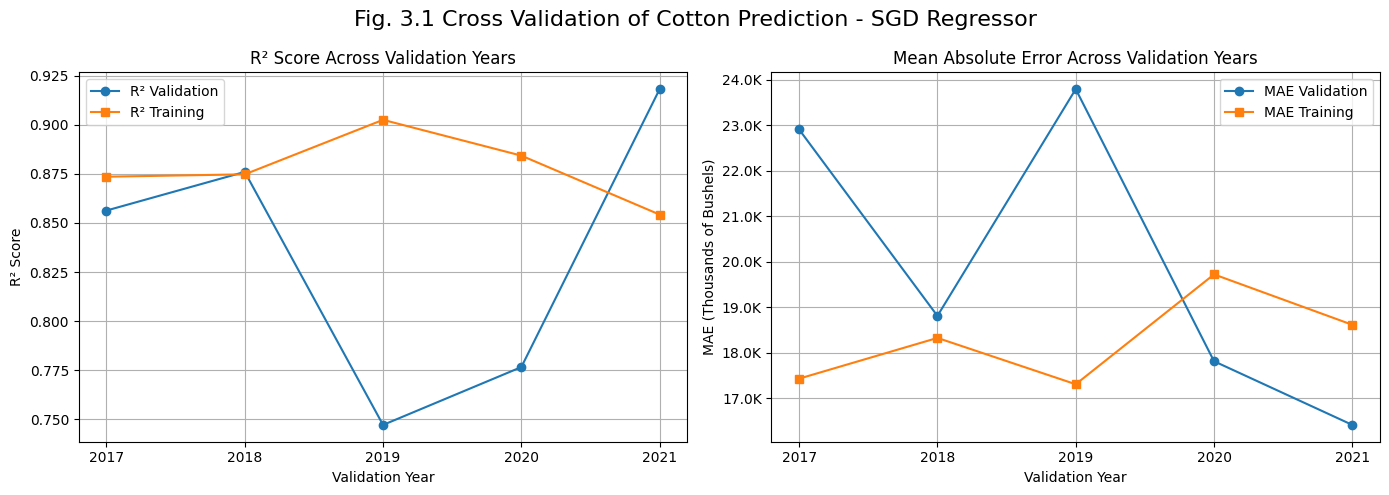

                                      Metric    Train Validation
0                               Avg R2 Score     0.88       0.83
1              Avg Mean Absolute Error (MAE)   18.28K     19.94K
2         Avg Root Mean Squared Error (RMSE)   26.95K     29.13K
3  Avg Mean Absolute Percentage Error (MAPE)   58.61%     65.91%
4                              Avg Max Error  126.87K    123.50K


In [136]:

cotton_cross_val_training_result_complete_features_SGD = helper.perform_cross_validation(train_set=train_set_complete_cotton, 
                                                                 target_column=cotton_target, 
                                                                 scaler=standard_scaler_cotton_complete,
                                                                 model=SGDRegressor(random_state=42, **best_sgd_cotton['params']))
helper.plot_cross_validation_result(cotton_cross_val_training_result_complete_features_SGD, title="Fig. 3.1 Cross Validation of Cotton Prediction - SGD Regressor")

#### 3.1.2 Log Transformation + Standard Scaler

In [60]:
sgd_grid_search_results_cotton_log_transformed = []
count = 1
for params in sgd_param_combinations:
    model = SGDRegressor(random_state=42, **params)
    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_cotton_data, cotton_target,
        scaler=standard_scaler_cotton_complete, model=model,
        verbose=False, max_safe_exp=100
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    sgd_grid_search_results_cotton_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(sgd_param_combinations)}", end='', flush=True)
    count += 1
    
best_sgd_cotton_log_transformed = max(sgd_grid_search_results_cotton_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SGDRegressor Cotton Prediction Grid Search Result")
print("  Best params:", best_sgd_cotton_log_transformed['params'])
print("  Mean R²:", best_sgd_cotton_log_transformed['mean_r2'])
print("  Mean MAE:", best_sgd_cotton_log_transformed['mean_mae'])

Grid Search Process: 140/140
SGDRegressor Cotton Prediction Grid Search Result
  Best params: {'penalty': 'l1', 'alpha': 0.05, 'learning_rate': 'constant', 'eta0': 0.01}
  Mean R²: 0.8661011634118788
  Mean MAE: 16762.006378761365


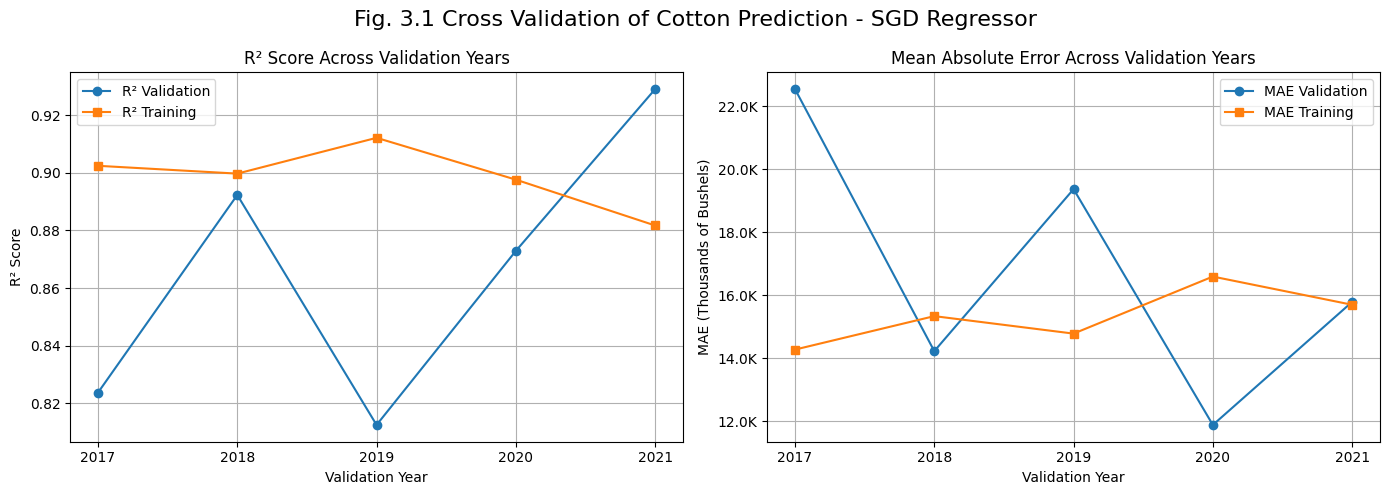

                                      Metric    Train Validation
0                               Avg R2 Score     0.90       0.87
1              Avg Mean Absolute Error (MAE)   15.34K     16.76K
2         Avg Root Mean Squared Error (RMSE)   24.59K     26.95K
3  Avg Mean Absolute Percentage Error (MAPE)   30.39%     32.08%
4                              Avg Max Error  132.94K    123.92K


In [137]:

cotton_cross_val_training_result_complete_features_SGD_log_transformed = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_cotton_data, 
        cotton_target,
        scaler=standard_scaler_cotton_complete, 
        model=SGDRegressor(random_state=42, **best_sgd_cotton_log_transformed['params']),
        verbose=False, max_safe_exp=100)
helper.plot_cross_validation_result(cotton_cross_val_training_result_complete_features_SGD_log_transformed, title="Fig. 3.1 Cross Validation of Cotton Prediction - SGD Regressor")

### 3.2 SVR Regressor

#### 3.2.1 Standard Scaler Only

In [62]:

svr_grid_search_results_cotton = []
count = 1
for params in svr_param_combinations:
    model = SVR(**params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_complete_cotton,
        target_column=cotton_target,
        model=model,
        scaler=standard_scaler_cotton_complete,  # SVR is scale-sensitive
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    svr_grid_search_results_cotton.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(svr_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_svr_param_cotton = max(svr_grid_search_results_cotton, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SVR Cotton Prediction Grid Search Result")
print("  Best params:", best_svr_param_cotton['params'])
print("  Mean R²:", best_svr_param_cotton['mean_r2'])
print("  Mean MAE:", best_svr_param_cotton['mean_mae'])


Grid Search Process: 144/144
SVR Cotton Prediction Grid Search Result
  Best params: {'kernel': 'rbf', 'C': 100000, 'epsilon': 50, 'gamma': 'scale'}
  Mean R²: 0.8421216977358055
  Mean MAE: 18654.761213724745


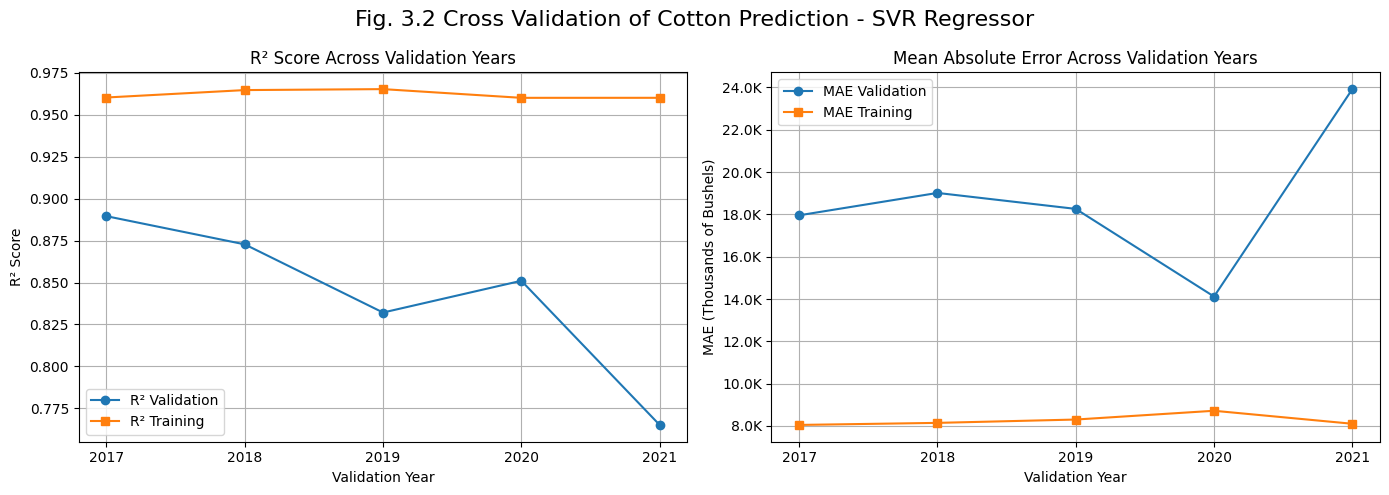

                                      Metric   Train Validation
0                               Avg R2 Score    0.96       0.84
1              Avg Mean Absolute Error (MAE)   8.26K     18.65K
2         Avg Root Mean Squared Error (RMSE)  15.07K     29.76K
3  Avg Mean Absolute Percentage Error (MAPE)  17.73%     56.83%
4                              Avg Max Error  84.26K    130.67K


In [138]:
cotton_cross_val_training_result_complete_features_SVR = helper.perform_cross_validation(train_set=train_set_complete_cotton, 
                                                                 target_column=cotton_target, 
                                                                 scaler=standard_scaler_cotton_complete,
                                                                 model=SVR(**best_svr_param_cotton['params']))
helper.plot_cross_validation_result(cotton_cross_val_training_result_complete_features_SVR, title="Fig. 3.2 Cross Validation of Cotton Prediction - SVR Regressor")

#### 3.2.2 Log Transformation + Standard Scaler

In [64]:
svr_grid_search_results_cotton_log_transformed = []
count = 1
for params in svr_param_combinations_log_transformed:
    model = SVR(**params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_cotton_data, 
        cotton_target,
        scaler=standard_scaler_cotton_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    svr_grid_search_results_cotton_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(svr_param_combinations_log_transformed)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_svr_param_cotton_log_transformed = max(svr_grid_search_results_cotton_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SVR Cotton Prediction Grid Search Result")
print("  Best params:", best_svr_param_cotton_log_transformed['params'])
print("  Mean R²:", best_svr_param_cotton_log_transformed['mean_r2'])
print("  Mean MAE:", best_svr_param_cotton_log_transformed['mean_mae'])


Grid Search Process: 60/60
SVR Cotton Prediction Grid Search Result
  Best params: {'kernel': 'linear', 'C': 1, 'epsilon': 0.1}
  Mean R²: 0.8003583092363996
  Mean MAE: 20311.876151814307


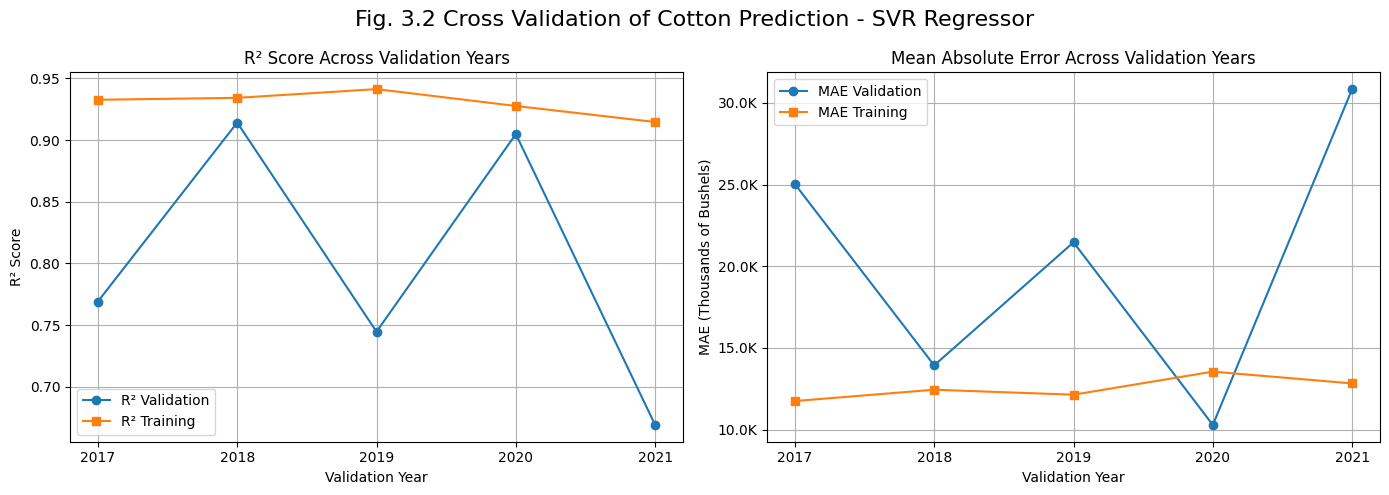

                                      Metric    Train Validation
0                               Avg R2 Score     0.93       0.80
1              Avg Mean Absolute Error (MAE)   12.54K     20.31K
2         Avg Root Mean Squared Error (RMSE)   20.40K     33.60K
3  Avg Mean Absolute Percentage Error (MAPE)   25.06%     32.62%
4                              Avg Max Error  117.13K    139.04K


In [139]:
cotton_cross_val_training_result_complete_features_SVR_log_transformed = helper.perform_cv_with_precomputed_transforms(
    precomputed_log_transformed_cotton_data, 
    cotton_target,
    scaler=standard_scaler_cotton_complete, 
    verbose=False, max_safe_exp=100,
    model=SVR(**best_svr_param_cotton_log_transformed['params']), 
)
helper.plot_cross_validation_result(cotton_cross_val_training_result_complete_features_SVR_log_transformed, title="Fig. 3.2 Cross Validation of Cotton Prediction - SVR Regressor")

### 3.3 Random Forest Regressor

#### 3.3.1 Standard Scaler Only

In [66]:
rf_grid_search_results_cotton = []
count = 1
for params in rf_param_combinations:
    model = RandomForestRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_complete_cotton,
        target_column=cotton_target,
        model=model,
        scaler=standard_scaler_cotton_complete  # scaling is optional for tree-based models but kept for uniformity
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    rf_grid_search_results_cotton.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(rf_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_rf_param_cotton = max(rf_grid_search_results_cotton, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("Random Forest Cotton Prediction Grid Search Result")
print("  Best params:", best_rf_param_cotton['params'])
print("  Mean R²:", best_rf_param_cotton['mean_r2'])
print("  Mean MAE:", best_rf_param_cotton['mean_mae'])

Grid Search Process: 324/324
Random Forest Cotton Prediction Grid Search Result
  Best params: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None}
  Mean R²: 0.8830798398058379
  Mean MAE: 14756.173304493228


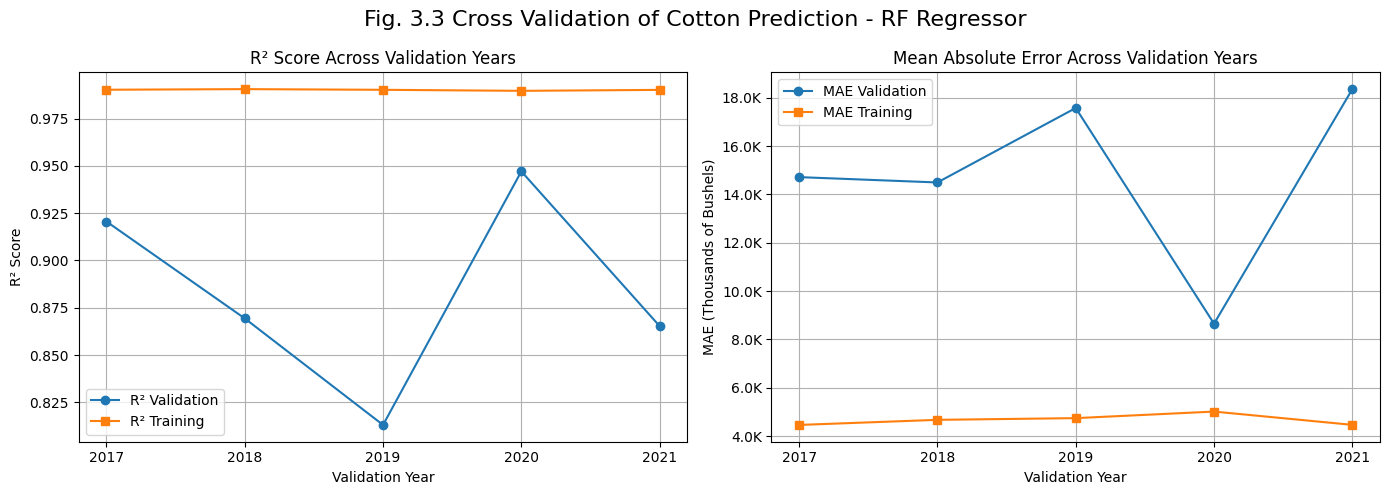

                                      Metric   Train Validation
0                               Avg R2 Score    0.99       0.88
1              Avg Mean Absolute Error (MAE)   4.67K     14.76K
2         Avg Root Mean Squared Error (RMSE)   7.65K     25.35K
3  Avg Mean Absolute Percentage Error (MAPE)  10.86%     30.46%
4                              Avg Max Error  47.72K    116.01K


In [140]:
cotton_cross_val_training_result_complete_features_RF = helper.perform_cross_validation(train_set=train_set_complete_cotton, 
                                                                 target_column=cotton_target, 
                                                                 scaler=standard_scaler_cotton_complete,
                                                                 model=RandomForestRegressor(random_state=42, **best_rf_param_cotton['params']))
helper.plot_cross_validation_result(cotton_cross_val_training_result_complete_features_RF, title="Fig. 3.3 Cross Validation of Cotton Prediction - RF Regressor")

#### 3.3.2 Log Transformation + Standard Scaler

In [68]:
rf_grid_search_results_cotton_log_transformed = []
count = 1
for params in rf_param_combinations:
    model = RandomForestRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_cotton_data, 
        cotton_target,
        scaler=standard_scaler_cotton_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )
    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    rf_grid_search_results_cotton_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(rf_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_rf_param_cotton_log_transformed = max(rf_grid_search_results_cotton_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("Random Forest Cotton Prediction Grid Search Result")
print("  Best params:", best_rf_param_cotton_log_transformed['params'])
print("  Mean R²:", best_rf_param_cotton_log_transformed['mean_r2'])
print("  Mean MAE:", best_rf_param_cotton_log_transformed['mean_mae'])

Grid Search Process: 324/324
Random Forest Cotton Prediction Grid Search Result
  Best params: {'n_estimators': 50, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None}
  Mean R²: 0.8790884753918912
  Mean MAE: 15182.077020300614


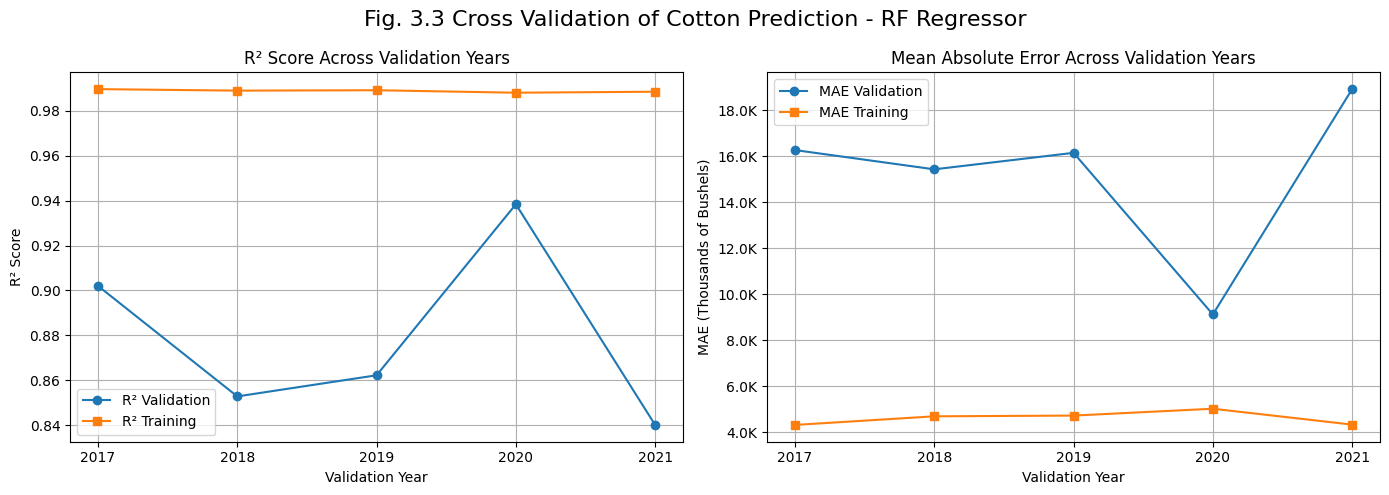

                                      Metric   Train Validation
0                               Avg R2 Score    0.99       0.88
1              Avg Mean Absolute Error (MAE)   4.63K     15.18K
2         Avg Root Mean Squared Error (RMSE)   8.17K     26.23K
3  Avg Mean Absolute Percentage Error (MAPE)   8.73%     28.08%
4                              Avg Max Error  57.98K    119.33K


In [141]:
cotton_cross_val_training_result_complete_features_RF_log_transformed = helper.perform_cv_with_precomputed_transforms(
    precomputed_log_transformed_cotton_data, 
    cotton_target,
    scaler=standard_scaler_cotton_complete, 
    verbose=False, 
    max_safe_exp=100,
    model=RandomForestRegressor(random_state=42, **best_rf_param_cotton_log_transformed['params']),
)
helper.plot_cross_validation_result(cotton_cross_val_training_result_complete_features_RF_log_transformed, title="Fig. 3.3 Cross Validation of Cotton Prediction - RF Regressor")

### 3.4 MLP Regressor

#### 3.4.1 Standard Scaler Only

In [70]:
mlp_grid_search_results_cotton = []
count = 1
for params in mlp_param_combinations:
    model = MLPRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_complete_cotton,
        target_column=cotton_target,
        model=model,
        scaler=standard_scaler_cotton_complete  # MLP is scale-sensitive
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    mlp_grid_search_results_cotton.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(mlp_param_combinations)}", end='', flush=True)
    count += 1

best_mlp_param_cotton = max(mlp_grid_search_results_cotton, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("MLPRegressor Cotton Prediction Grid Search Result")
print("  Best params:", best_mlp_param_cotton['params'])
print("  Mean R²:", best_mlp_param_cotton['mean_r2'])
print("  Mean MAE:", best_mlp_param_cotton['mean_mae'])

Grid Search Process: 16/16
MLPRegressor Cotton Prediction Grid Search Result
  Best params: {'hidden_layer_sizes': (50, 100, 50), 'activation': 'relu', 'solver': 'adam', 'alpha': 5, 'learning_rate': 'constant', 'learning_rate_init': 0.1, 'max_iter': 30000}
  Mean R²: 0.9023981092012401
  Mean MAE: 16419.85796582519


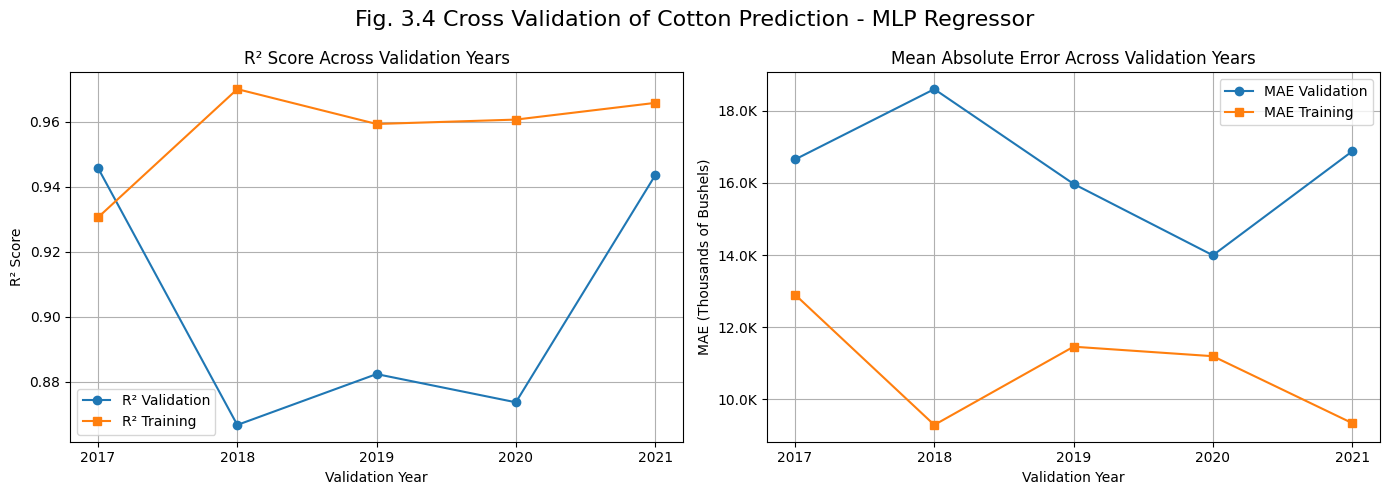

                                      Metric   Train Validation
0                               Avg R2 Score    0.96       0.90
1              Avg Mean Absolute Error (MAE)  10.84K     16.42K
2         Avg Root Mean Squared Error (RMSE)  15.77K     22.36K
3  Avg Mean Absolute Percentage Error (MAPE)  38.79%     56.77%
4                              Avg Max Error  86.30K     85.09K


In [142]:
cotton_cross_val_training_result_complete_features_MLP = helper.perform_cross_validation(train_set=train_set_complete_cotton, 
                                                                 target_column=cotton_target, 
                                                                 scaler=standard_scaler_cotton_complete,
                                                                 model=MLPRegressor(random_state=42, **best_mlp_param_cotton['params']))
helper.plot_cross_validation_result(cotton_cross_val_training_result_complete_features_MLP, title="Fig. 3.4 Cross Validation of Cotton Prediction - MLP Regressor")

#### 3.4.2 Log Transformation + Standard Scaler

In [72]:
mlp_grid_search_results_cotton_log_transformed = []
cotton = 1
for params in mlp_param_combinations:
    model = MLPRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_cotton_data, 
        cotton_target,
        scaler=standard_scaler_cotton_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    mlp_grid_search_results_cotton_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(mlp_param_combinations)}", end='', flush=True)
    count += 1

best_mlp_param_cotton_log_transformed = max(mlp_grid_search_results_cotton_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("MLPRegressor Cotton Prediction Grid Search Result")
print("  Best params:", best_mlp_param_cotton_log_transformed['params'])
print("  Mean R²:", best_mlp_param_cotton_log_transformed['mean_r2'])
print("  Mean MAE:", best_mlp_param_cotton_log_transformed['mean_mae'])

Grid Search Process: 32/16
MLPRegressor Cotton Prediction Grid Search Result
  Best params: {'hidden_layer_sizes': (50, 100, 50), 'activation': 'relu', 'solver': 'adam', 'alpha': 5, 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_iter': 30000}
  Mean R²: 0.8434153230664316
  Mean MAE: 18024.476453902134


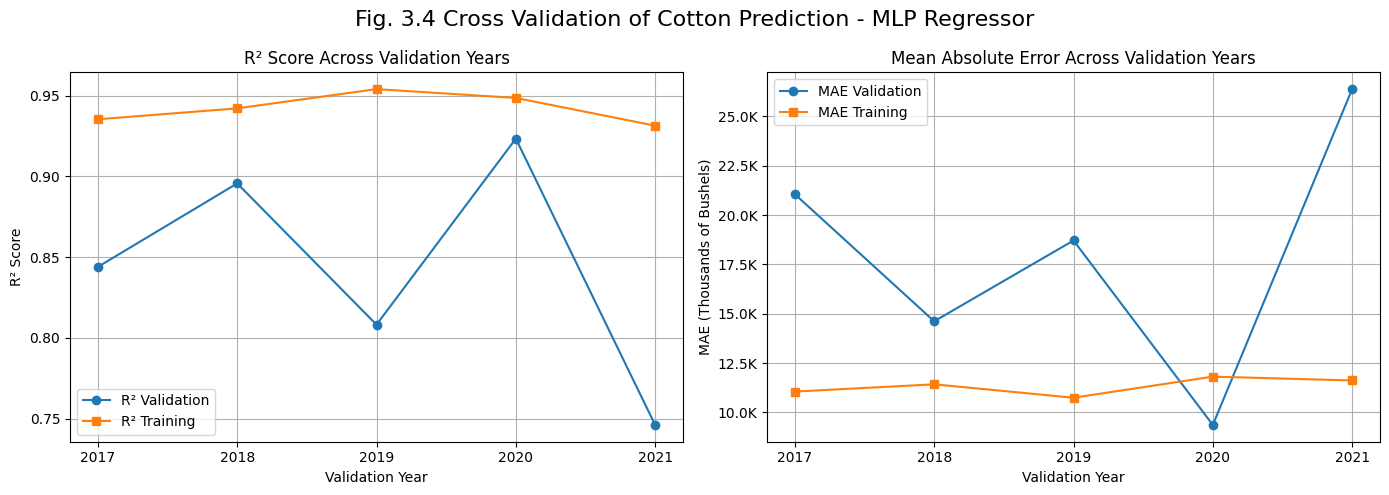

                                      Metric    Train Validation
0                               Avg R2 Score     0.94       0.84
1              Avg Mean Absolute Error (MAE)   11.33K     18.02K
2         Avg Root Mean Squared Error (RMSE)   18.51K     29.94K
3  Avg Mean Absolute Percentage Error (MAPE)   21.76%     30.19%
4                              Avg Max Error  112.31K    130.45K


In [143]:
cotton_cross_val_training_result_complete_features_MLP_log_transformed = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_cotton_data, 
        cotton_target,
        scaler=standard_scaler_cotton_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=MLPRegressor(random_state=42, **best_mlp_param_cotton_log_transformed['params'])
)
helper.plot_cross_validation_result(cotton_cross_val_training_result_complete_features_MLP_log_transformed, title="Fig. 3.4 Cross Validation of Cotton Prediction - MLP Regressor")

### 3.5 HGBoost Regressor

#### 3.5.1 Standard Scaler Only

In [104]:
hgb_grid_search_results_cotton = []
count = 1
for params in hgb_param_combinations:
    model = HistGradientBoostingRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_complete_cotton,
        target_column=cotton_target,
        model=model,
        scaler=standard_scaler_cotton_complete
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    hgb_grid_search_results_cotton.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(hgb_param_combinations)}", end='', flush=True)
    count += 1

best_hgb_param_cotton = max(hgb_grid_search_results_cotton, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("HGBoost Regressor Cotton Prediction Grid Search Result")
print("  Best params:", best_hgb_param_cotton['params'])
print("  Mean R²:", best_hgb_param_cotton['mean_r2'])
print("  Mean MAE:", best_hgb_param_cotton['mean_mae'])

Grid Search Process: 360/360
HGBoost Regressor Cotton Prediction Grid Search Result
  Best params: {'learning_rate': 0.05, 'max_iter': 500, 'max_depth': None, 'l2_regularization': 5.0, 'min_samples_leaf': 20}
  Mean R²: 0.8847945692879033
  Mean MAE: 14938.914041032913


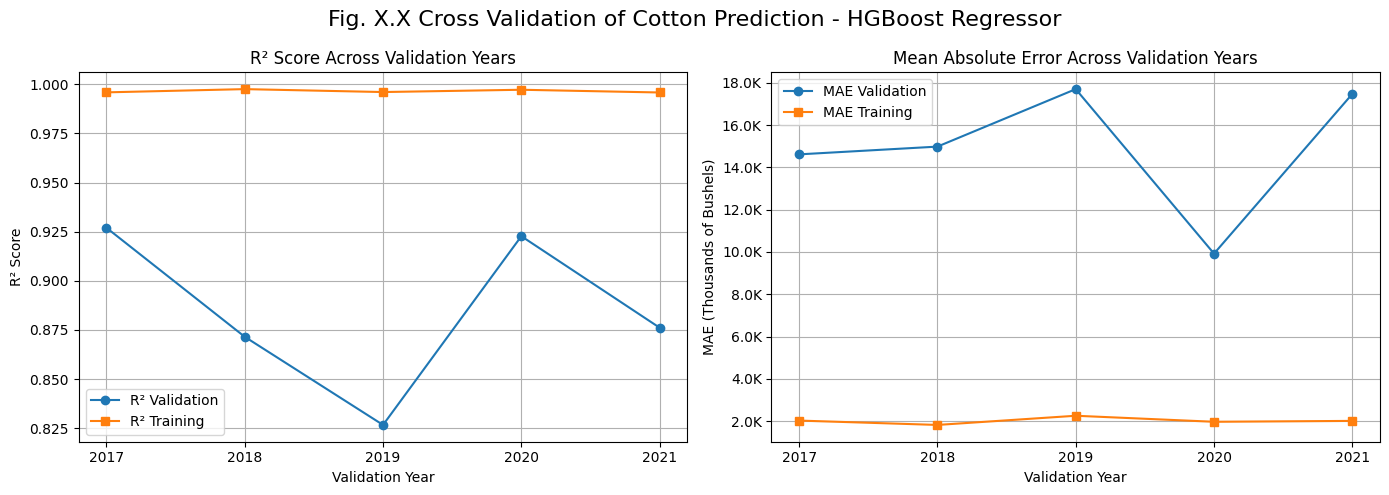

                                      Metric   Train Validation
0                               Avg R2 Score    1.00       0.88
1              Avg Mean Absolute Error (MAE)   2.01K     14.94K
2         Avg Root Mean Squared Error (RMSE)   4.52K     25.14K
3  Avg Mean Absolute Percentage Error (MAPE)   5.06%     35.27%
4                              Avg Max Error  37.63K    115.77K


In [144]:

cotton_cross_val_training_result_complete_features_hgb = helper.perform_cross_validation(train_set=train_set_complete_cotton, 
                                                                 target_column=cotton_target, 
                                                                 scaler=standard_scaler_cotton_complete,
                                                                 model=HistGradientBoostingRegressor(random_state=42, **best_hgb_param_cotton['params']))
helper.plot_cross_validation_result(cotton_cross_val_training_result_complete_features_hgb, title="Fig. X.X Cross Validation of Cotton Prediction - HGBoost Regressor")

#### 3.5.2 Log Transformation + Standard Scaler

In [106]:
hgb_grid_search_results_cotton_log_transformed = []
count = 1
for params in hgb_param_combinations:
    model = HistGradientBoostingRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_cotton_data, 
        cotton_target,
        scaler=standard_scaler_cotton_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    hgb_grid_search_results_cotton_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(hgb_param_combinations)}", end='', flush=True)
    count += 1

best_hgb_param_cotton_log_transformed = max(hgb_grid_search_results_cotton_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("HGBoost Regressor Cotton Prediction Grid Search Result")
print("  Best params:", best_hgb_param_cotton_log_transformed['params'])
print("  Mean R²:", best_hgb_param_cotton_log_transformed['mean_r2'])
print("  Mean MAE:", best_hgb_param_cotton_log_transformed['mean_mae'])

Grid Search Process: 360/360
HGBoost Regressor Cotton Prediction Grid Search Result
  Best params: {'learning_rate': 0.1, 'max_iter': 100, 'max_depth': 10, 'l2_regularization': 1.0, 'min_samples_leaf': 20}
  Mean R²: 0.8856209875663626
  Mean MAE: 14634.1224112102


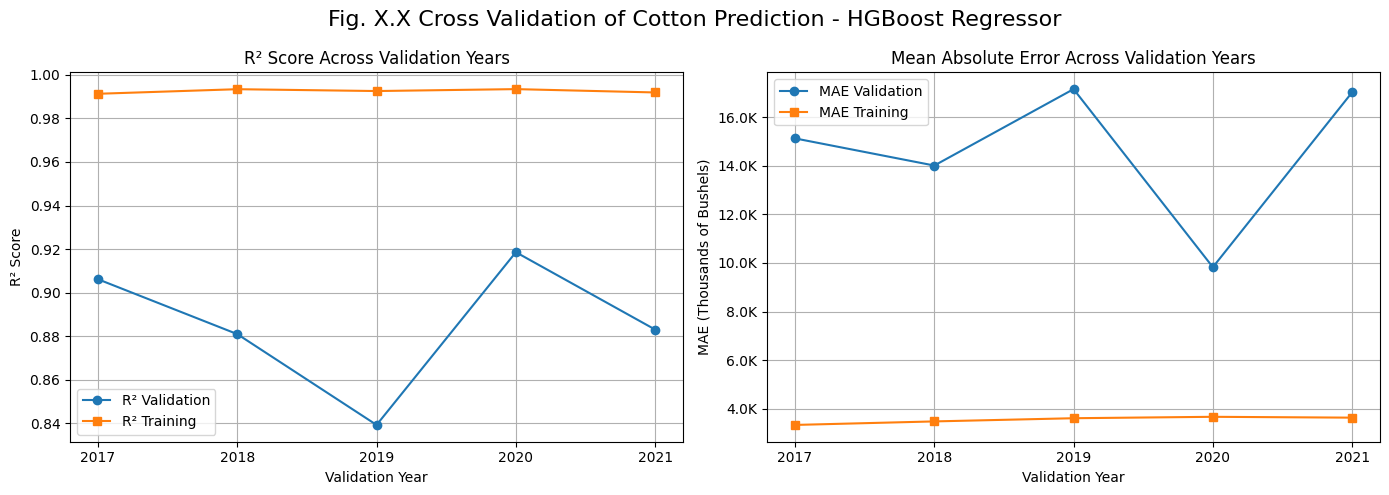

                                      Metric   Train Validation
0                               Avg R2 Score    0.99       0.89
1              Avg Mean Absolute Error (MAE)   3.54K     14.63K
2         Avg Root Mean Squared Error (RMSE)   6.69K     25.29K
3  Avg Mean Absolute Percentage Error (MAPE)   7.10%     28.42%
4                              Avg Max Error  54.20K    122.78K


In [145]:

cotton_cross_val_training_result_complete_features_hgb_log_transformed =  helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_cotton_data, 
        cotton_target,
        scaler=standard_scaler_cotton_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=HistGradientBoostingRegressor(random_state=42, **best_hgb_param_cotton_log_transformed['params'])
)
helper.plot_cross_validation_result(cotton_cross_val_training_result_complete_features_hgb_log_transformed, title="Fig. X.X Cross Validation of Cotton Prediction - HGBoost Regressor")

## 4. Wheat Prediction

In [74]:
wheat_target = 'PRODUCTION, MEASURED IN BU'

In [75]:
merged_wheat_dataset = pd.read_csv(merged_weather_and_wheat_production_data_dir)

complete_wheat_dataset = merged_wheat_dataset.drop(["Unnamed: 0", "State", "County", "FIPS Code"], axis=1)
complete_wheat_dataset

,Avg Temperature (C),Max Temperature (C),Min Temperature (C),Heat_Stress_Day,Cold_Stress_Day,Precipitation (mm),Vapor Pressure Deficit (kPa),Drought_Stress_Day,Wet_Day,Heavy_Rain_Day,Solar Radiation (MJ m**-2 day**-1),Low_Light_Day,Relative Humidity (%),Wind Speed (m s**-1),Year,"PRODUCTION, MEASURED IN BU",harvested_area
0,18.603199,35.795500,-8.312000,3.700000,108.800000,1844.636750,0.683657,0.000000,113.000000,23.200000,122775.899299,11.200000,73.309178,5.077573,2017,76000.0,1200.631912
1,17.073877,35.524000,-13.501000,3.500000,138.600000,1545.755900,0.672345,0.000000,106.700000,17.400000,128836.079107,8.900000,71.646164,5.383557,2017,282000.0,4298.780488
2,17.776995,35.603571,-11.829643,3.428571,129.285714,1674.127393,0.694004,0.000000,98.821429,20.535714,128384.228831,5.892857,71.776575,5.074015,2017,240000.0,5405.405405
3,17.374002,35.664286,-13.952857,5.142857,132.428571,1581.354643,0.662848,0.000000,105.428571,16.642857,132428.745516,6.642857,72.692975,5.409999,2017,225000.0,4697.286013
4,17.963515,34.832143,-12.094286,1.000000,125.571429,1779.666429,0.671998,0.000000,103.500000,19.785714,127787.722613,7.357143,72.480763,5.143745,2017,206000.0,4497.816594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1193,20.250513,41.017857,-10.844286,78.023810,103.357143,553.008690,1.105926,10.095238,46.571429,6.523810,153875.616961,16.476190,63.261735,3.714269,2022,233000.0,6676.217765
1194,21.392574,41.521429,-7.938214,104.214286,95.928571,329.569571,1.156840,3.892857,37.928571,3.142857,154536.885121,15.178571,63.404912,4.083249,2022,5000.0,230.414747
1195,18.878895,43.502500,-12.648500,77.500000,130.000000,574.534350,1.242541,41.300000,43.050000,6.850000,155632.124477,15.000000,56.900205,3.706686,2022,44600.0,2207.920792
1196,16.195158,40.266875,-15.552500,55.875000,170.812500,188.818000,1.350214,54.375000,30.875000,0.437500,176941.193213,12.687500,46.753596,4.302007,2022,19800.0,1980.000000


In [76]:
train_set_complete_wheat, test_set_complete_wheat = helper.split_dataset_by_year(complete_wheat_dataset, 2022)
standard_scaler_wheat_complete = StandardScaler()

In [77]:
X_test_complete_wheat = test_set_complete_wheat.drop(columns=[wheat_target])
y_test_complete_wheat = test_set_complete_wheat[wheat_target]

In [78]:
precomputed_log_transformed_wheat_data = helper.precompute_transformations_by_fold(
        train_set_complete_wheat, wheat_target,
        feature_skew_threshold=1.0,
        target_skew_threshold=1.0,
        verbose=False
)

### 4.1 SGD Regressor

#### 4.1.1 Standard Scaler Only

In [79]:
sgd_grid_search_results_wheat = []
count = 1
for params in sgd_param_combinations:
    model = SGDRegressor(random_state=42, **params)
    cv_result = helper.perform_cross_validation(
        train_set=train_set_complete_wheat,
        target_column=wheat_target,
        model=model,
        scaler=standard_scaler_wheat_complete,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    sgd_grid_search_results_wheat.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(sgd_param_combinations)}", end='', flush=True)
    count += 1
    
best_sgd_wheat = max(sgd_grid_search_results_wheat, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SGDRegressor Wheat Prediction Grid Search Result")
print("  Best params:", best_sgd_wheat['params'])
print("  Mean R²:", best_sgd_wheat['mean_r2'])
print("  Mean MAE:", best_sgd_wheat['mean_mae'])

Grid Search Process: 140/140
SGDRegressor Wheat Prediction Grid Search Result
  Best params: {'penalty': 'l2', 'alpha': 0.1, 'learning_rate': 'constant', 'eta0': 0.01}
  Mean R²: 0.9039144079985377
  Mean MAE: 427452.5636714773


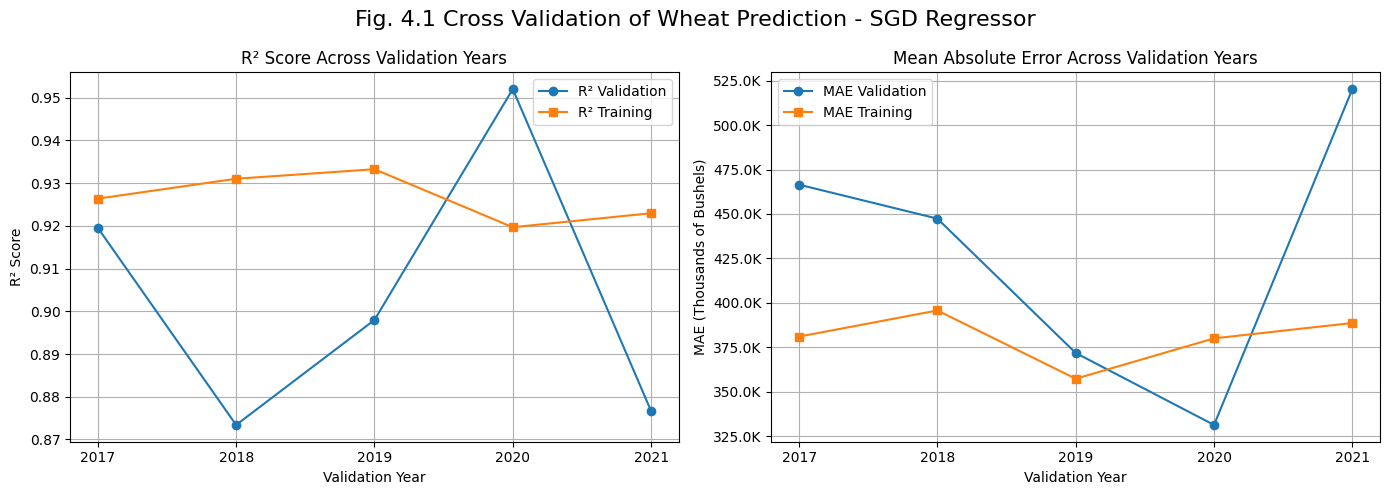

                                      Metric    Train Validation
0                               Avg R2 Score     0.93       0.90
1              Avg Mean Absolute Error (MAE)  380.58K    427.45K
2         Avg Root Mean Squared Error (RMSE)  588.50K    655.33K
3  Avg Mean Absolute Percentage Error (MAPE)  113.76%    123.73%
4                              Avg Max Error    3.83M      3.41M


In [146]:

wheat_cross_val_training_result_complete_features_SGD = helper.perform_cross_validation(train_set=train_set_complete_wheat, 
                                                                 target_column=wheat_target, 
                                                                 scaler=standard_scaler_wheat_complete,
                                                                 model=SGDRegressor(random_state=42, **best_sgd_wheat['params']))
helper.plot_cross_validation_result(wheat_cross_val_training_result_complete_features_SGD, title="Fig. 4.1 Cross Validation of Wheat Prediction - SGD Regressor")

#### 4.1.2 Log Transformation + Standard Scaler

In [81]:
sgd_grid_search_results_wheat_log_transformed = []
count = 1
for params in sgd_param_combinations:
    model = SGDRegressor(random_state=42, **params)
    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_wheat_data, wheat_target,
        scaler=standard_scaler_wheat_complete, model=model,
        verbose=False, max_safe_exp=100
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    sgd_grid_search_results_wheat_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(sgd_param_combinations)}", end='', flush=True)
    count += 1
    
best_sgd_wheat_log_transformed = max(sgd_grid_search_results_wheat_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SGDRegressor Wheat Prediction Grid Search Result")
print("  Best params:", best_sgd_wheat_log_transformed['params'])
print("  Mean R²:", best_sgd_wheat_log_transformed['mean_r2'])
print("  Mean MAE:", best_sgd_wheat_log_transformed['mean_mae'])

Grid Search Process: 140/140
SGDRegressor Wheat Prediction Grid Search Result
  Best params: {'penalty': 'l1', 'alpha': 0.05, 'learning_rate': 'constant', 'eta0': 0.005}
  Mean R²: 0.9107829027088602
  Mean MAE: 338762.6481126583


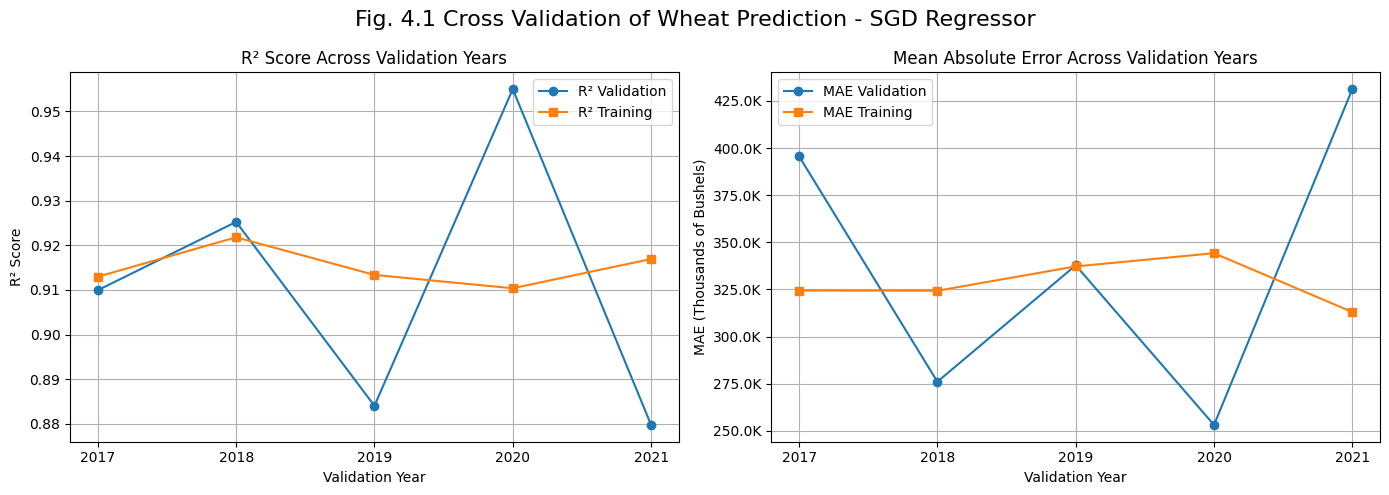

                                      Metric    Train Validation
0                               Avg R2 Score     0.92       0.91
1              Avg Mean Absolute Error (MAE)  328.63K    338.76K
2         Avg Root Mean Squared Error (RMSE)  633.46K    637.53K
3  Avg Mean Absolute Percentage Error (MAPE)   26.83%     27.68%
4                              Avg Max Error    4.30M      3.58M


In [147]:

wheat_cross_val_training_result_complete_features_SGD_log_transformed = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_wheat_data, 
        wheat_target,
        scaler=standard_scaler_wheat_complete, 
        model=SGDRegressor(random_state=42, **best_sgd_wheat_log_transformed['params']),
        verbose=False, max_safe_exp=100)
helper.plot_cross_validation_result(wheat_cross_val_training_result_complete_features_SGD_log_transformed, title="Fig. 4.1 Cross Validation of Wheat Prediction - SGD Regressor")

### 4.2 SVR Regressor

#### 4.2.1 Standard Scaler Only

In [83]:
svr_grid_search_results_wheat = []
count = 1
for params in svr_param_combinations:
    model = SVR(**params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_complete_wheat,
        target_column=wheat_target,
        model=model,
        scaler=standard_scaler_wheat_complete,  # SVR is scale-sensitive
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    svr_grid_search_results_wheat.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(svr_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_svr_param_wheat = max(svr_grid_search_results_wheat, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SVR Wheat Prediction Grid Search Result")
print("  Best params:", best_svr_param_wheat['params'])
print("  Mean R²:", best_svr_param_wheat['mean_r2'])
print("  Mean MAE:", best_svr_param_wheat['mean_mae'])


Grid Search Process: 144/144
SVR Wheat Prediction Grid Search Result
  Best params: {'kernel': 'linear', 'C': 500000, 'epsilon': 50}
  Mean R²: 0.9028682021548278
  Mean MAE: 402465.31637587055


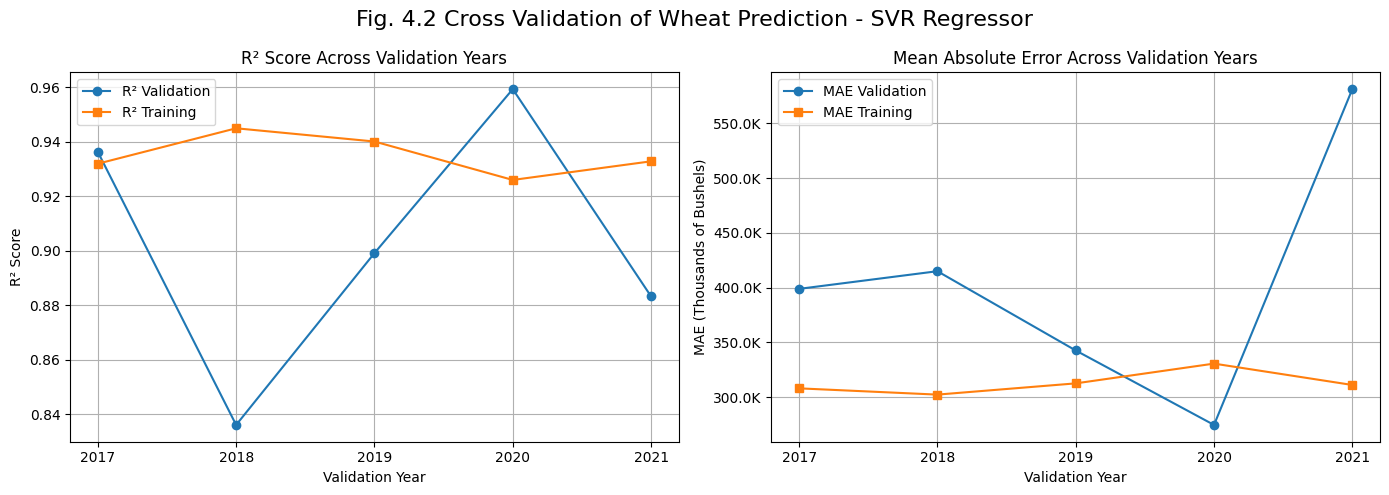

                                      Metric    Train Validation
0                               Avg R2 Score     0.94       0.90
1              Avg Mean Absolute Error (MAE)  312.87K    402.47K
2         Avg Root Mean Squared Error (RMSE)  552.55K    645.45K
3  Avg Mean Absolute Percentage Error (MAPE)   45.45%     79.03%
4                              Avg Max Error    4.06M      3.27M


In [148]:
wheat_cross_val_training_result_complete_features_SVR = helper.perform_cross_validation(train_set=train_set_complete_wheat, 
                                                                 target_column=wheat_target, 
                                                                 scaler=standard_scaler_wheat_complete,
                                                                 model=SVR(**best_svr_param_wheat['params']))
helper.plot_cross_validation_result(wheat_cross_val_training_result_complete_features_SVR, title="Fig. 4.2 Cross Validation of Wheat Prediction - SVR Regressor")

#### 4.2.2 Log Transformation + Standard Scaler

In [86]:
svr_grid_search_results_wheat_log_transformed = []
count = 1
for params in svr_param_combinations_log_transformed:
    model = SVR(**params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_wheat_data, 
        wheat_target,
        scaler=standard_scaler_wheat_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    svr_grid_search_results_wheat_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(svr_param_combinations_log_transformed)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_svr_param_wheat_log_transformed = max(svr_grid_search_results_wheat_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("SVR Wheat Prediction Grid Search Result")
print("  Best params:", best_svr_param_wheat_log_transformed['params'])
print("  Mean R²:", best_svr_param_wheat_log_transformed['mean_r2'])
print("  Mean MAE:", best_svr_param_wheat_log_transformed['mean_mae'])


Grid Search Process: 60/60
SVR Wheat Prediction Grid Search Result
  Best params: {'kernel': 'linear', 'C': 100, 'epsilon': 0.1}
  Mean R²: 0.8009632162459738
  Mean MAE: 473526.21975939657


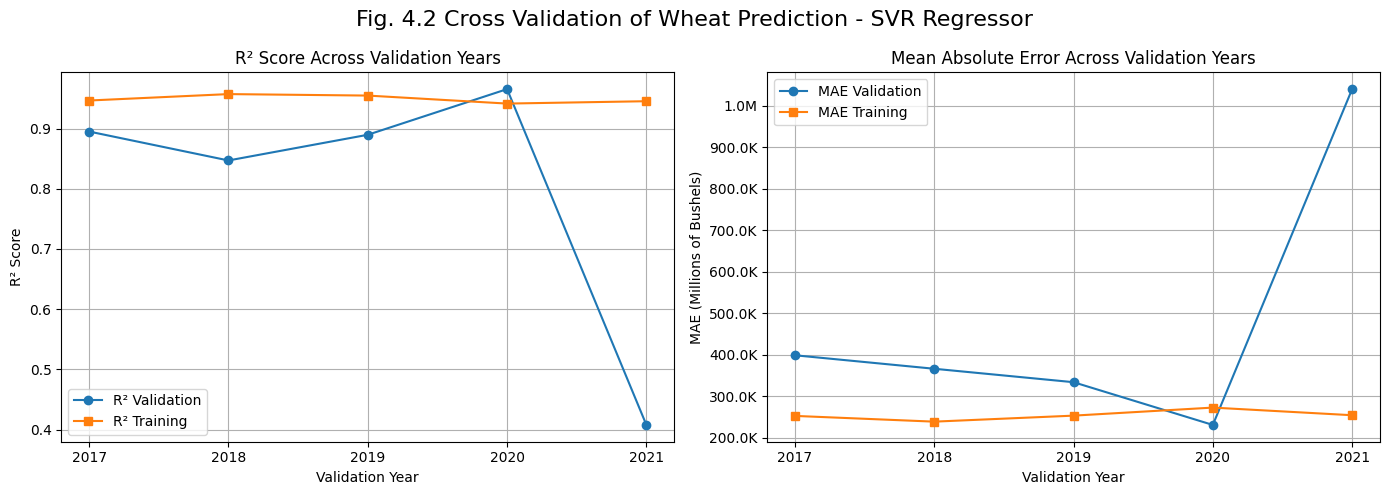

                                      Metric    Train Validation
0                               Avg R2 Score     0.95       0.80
1              Avg Mean Absolute Error (MAE)  253.92K    473.53K
2         Avg Root Mean Squared Error (RMSE)  489.79K    868.08K
3  Avg Mean Absolute Percentage Error (MAPE)   21.39%     30.35%
4                              Avg Max Error    3.84M      4.59M


In [149]:
wheat_cross_val_training_result_complete_features_SVR_log_transformed = helper.perform_cv_with_precomputed_transforms(
    precomputed_log_transformed_wheat_data, 
    wheat_target,
    scaler=standard_scaler_wheat_complete, 
    verbose=False, max_safe_exp=100,
    model=SVR(**best_svr_param_wheat_log_transformed['params']), 
)
helper.plot_cross_validation_result(wheat_cross_val_training_result_complete_features_SVR_log_transformed, title="Fig. 4.2 Cross Validation of Wheat Prediction - SVR Regressor")

### 4.3 Random Forest Regressor

#### 4.3.1 Standard Scaler Only

In [88]:
rf_grid_search_results_wheat = []
count = 1
for params in rf_param_combinations:
    model = RandomForestRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_complete_wheat,
        target_column=wheat_target,
        model=model,
        scaler=standard_scaler_wheat_complete  # scaling is optional for tree-based models but kept for uniformity
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    rf_grid_search_results_wheat.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(rf_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_rf_param_wheat = max(rf_grid_search_results_wheat, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("Random Forest Wheat Prediction Grid Search Result")
print("  Best params:", best_rf_param_wheat['params'])
print("  Mean R²:", best_rf_param_wheat['mean_r2'])
print("  Mean MAE:", best_rf_param_wheat['mean_mae'])

Grid Search Process: 324/324
Random Forest Wheat Prediction Grid Search Result
  Best params: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None}
  Mean R²: 0.911533995838362
  Mean MAE: 322226.6280919107


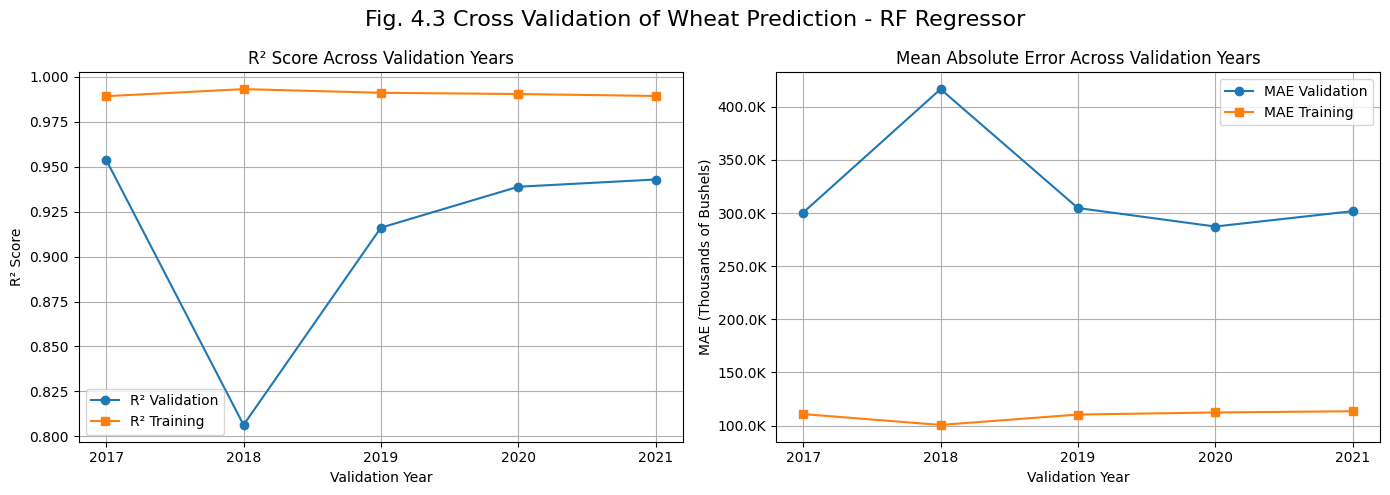

                                      Metric    Train Validation
0                               Avg R2 Score     0.99       0.91
1              Avg Mean Absolute Error (MAE)  109.52K    322.23K
2         Avg Root Mean Squared Error (RMSE)  210.41K    601.76K
3  Avg Mean Absolute Percentage Error (MAPE)   11.40%     26.64%
4                              Avg Max Error    1.78M      3.39M


In [150]:
wheat_cross_val_training_result_complete_features_RF = helper.perform_cross_validation(train_set=train_set_complete_wheat, 
                                                                 target_column=wheat_target, 
                                                                 scaler=standard_scaler_wheat_complete,
                                                                 model=RandomForestRegressor(random_state=42, **best_rf_param_wheat['params']))
helper.plot_cross_validation_result(wheat_cross_val_training_result_complete_features_RF, title="Fig. 4.3 Cross Validation of Wheat Prediction - RF Regressor")

#### 4.3.2 Log Transformation + Standard Scaler

In [90]:
rf_grid_search_results_wheat_log_transformed = []
count = 1
for params in rf_param_combinations:
    model = RandomForestRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_wheat_data, 
        wheat_target,
        scaler=standard_scaler_wheat_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    rf_grid_search_results_wheat_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(rf_param_combinations)}", end='', flush=True)
    count += 1

# Choose best based on highest R² and lowest MAE
best_rf_param_wheat_log_transformed = max(rf_grid_search_results_wheat_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("Random Forest Wheat Prediction Grid Search Result")
print("  Best params:", best_rf_param_wheat_log_transformed['params'])
print("  Mean R²:", best_rf_param_wheat_log_transformed['mean_r2'])
print("  Mean MAE:", best_rf_param_wheat_log_transformed['mean_mae'])

Grid Search Process: 324/324
Random Forest Wheat Prediction Grid Search Result
  Best params: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None}
  Mean R²: 0.908512648395696
  Mean MAE: 329062.79429757065


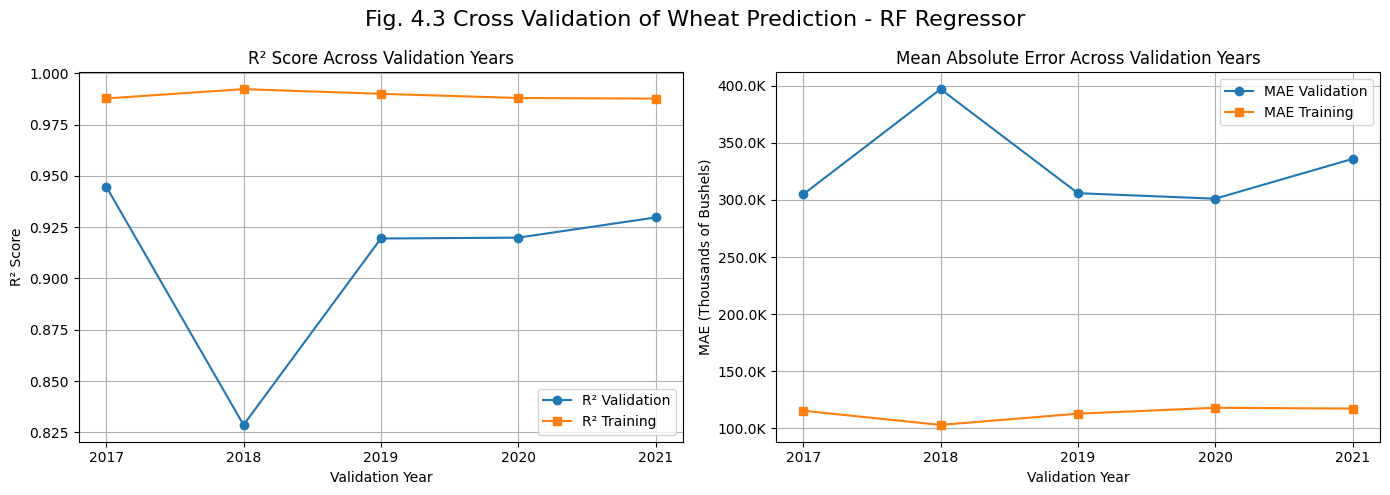

                                      Metric    Train Validation
0                               Avg R2 Score     0.99       0.91
1              Avg Mean Absolute Error (MAE)  113.15K    329.06K
2         Avg Root Mean Squared Error (RMSE)  224.90K    626.05K
3  Avg Mean Absolute Percentage Error (MAPE)    9.70%     25.37%
4                              Avg Max Error    2.00M      3.65M


In [151]:
wheat_cross_val_training_result_complete_features_RF_log_transformed = helper.perform_cv_with_precomputed_transforms(
    precomputed_log_transformed_wheat_data, 
    wheat_target,
    scaler=standard_scaler_wheat_complete, 
    verbose=False, 
    max_safe_exp=100,
    model=RandomForestRegressor(random_state=42, **best_rf_param_wheat_log_transformed['params']),
)
helper.plot_cross_validation_result(wheat_cross_val_training_result_complete_features_RF_log_transformed, title="Fig. 4.3 Cross Validation of Wheat Prediction - RF Regressor")

### 4.4 MLP Regressor

#### 4.4.1 Standard Scaler Only

In [92]:
mlp_grid_search_results_wheat = []
cotton = 1
for params in mlp_param_combinations:
    model = MLPRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_complete_wheat,
        target_column=wheat_target,
        model=model,
        scaler=standard_scaler_wheat_complete  # MLP is scale-sensitive
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    mlp_grid_search_results_wheat.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(mlp_param_combinations)}", end='', flush=True)
    count += 1

best_mlp_param_wheat = max(mlp_grid_search_results_wheat, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("MLPRegressor Wheat Prediction Grid Search Result")
print("  Best params:", best_mlp_param_wheat['params'])
print("  Mean R²:", best_mlp_param_wheat['mean_r2'])
print("  Mean MAE:", best_mlp_param_wheat['mean_mae'])

Grid Search Process: 340/16
MLPRegressor Wheat Prediction Grid Search Result
  Best params: {'hidden_layer_sizes': (50, 100, 50), 'activation': 'relu', 'solver': 'adam', 'alpha': 0.1, 'learning_rate': 'constant', 'learning_rate_init': 0.1, 'max_iter': 30000}
  Mean R²: 0.8594652887594829
  Mean MAE: 458048.014812478


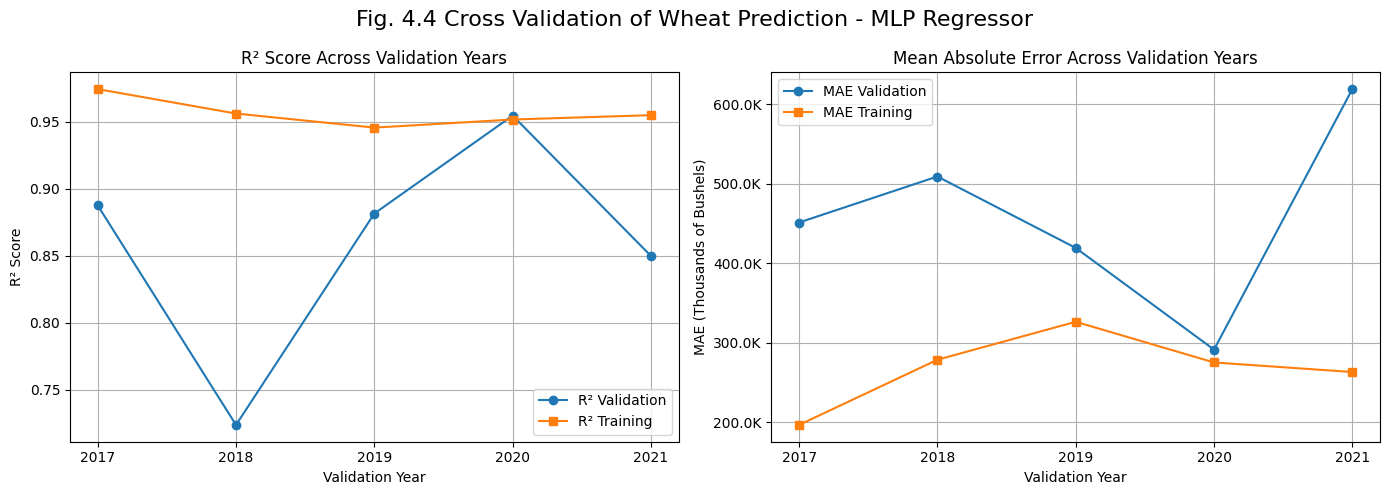

                                      Metric    Train Validation
0                               Avg R2 Score     0.96       0.86
1              Avg Mean Absolute Error (MAE)  267.92K    458.05K
2         Avg Root Mean Squared Error (RMSE)  450.03K    766.06K
3  Avg Mean Absolute Percentage Error (MAPE)   60.06%     82.16%
4                              Avg Max Error    3.44M      3.82M


In [152]:
standard_scaler_wheat_complete = StandardScaler()
wheat_cross_val_training_result_complete_features_MLP = helper.perform_cross_validation(train_set=train_set_complete_wheat, 
                                                                 target_column=wheat_target, 
                                                                 scaler=standard_scaler_wheat_complete,
                                                                 model=MLPRegressor(random_state=42, **best_mlp_param_wheat['params']))
helper.plot_cross_validation_result(wheat_cross_val_training_result_complete_features_MLP, title="Fig. 4.4 Cross Validation of Wheat Prediction - MLP Regressor")

#### 4.4.2 Log Transformation + Standard Scaler

In [94]:
mlp_grid_search_results_wheat_log_transformed = []
cotton = 1
for params in mlp_param_combinations:
    model = MLPRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_wheat_data, 
        wheat_target,
        scaler=standard_scaler_wheat_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    mlp_grid_search_results_wheat_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(mlp_param_combinations)}", end='', flush=True)
    count += 1

best_mlp_param_wheat_log_transformed = max(mlp_grid_search_results_wheat_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("MLPRegressor Wheat Prediction Grid Search Result")
print("  Best params:", best_mlp_param_wheat_log_transformed['params'])
print("  Mean R²:", best_mlp_param_wheat_log_transformed['mean_r2'])
print("  Mean MAE:", best_mlp_param_wheat_log_transformed['mean_mae'])

Grid Search Process: 356/16
MLPRegressor Wheat Prediction Grid Search Result
  Best params: {'hidden_layer_sizes': (50, 100, 50), 'activation': 'relu', 'solver': 'adam', 'alpha': 1, 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_iter': 30000}
  Mean R²: 0.8836520039323785
  Mean MAE: 384953.4811079126


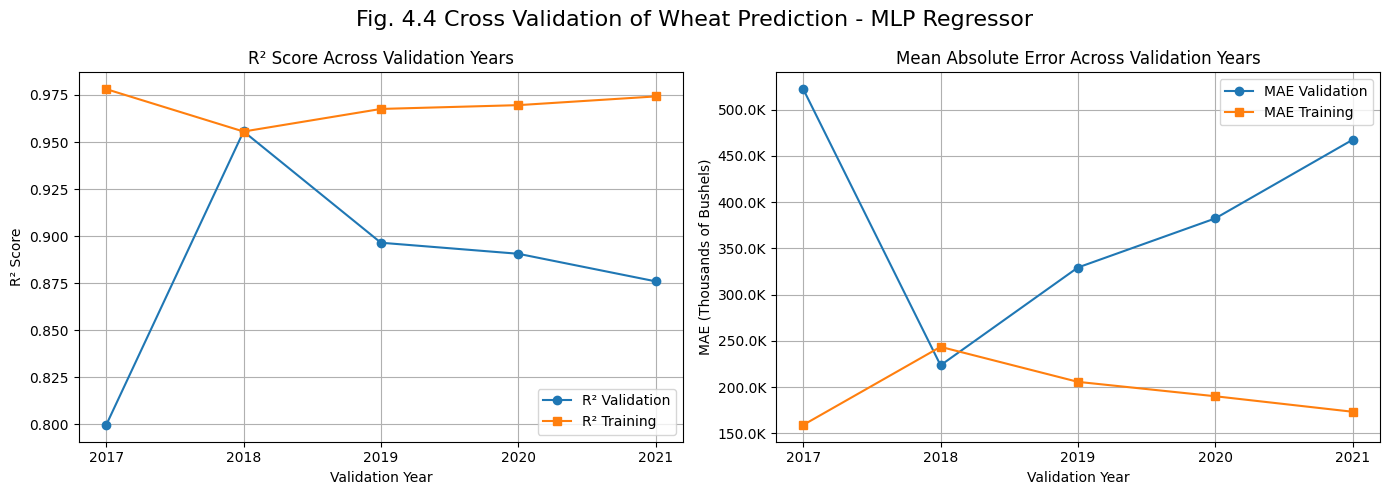

                                      Metric    Train Validation
0                               Avg R2 Score     0.97       0.88
1              Avg Mean Absolute Error (MAE)  194.29K    384.95K
2         Avg Root Mean Squared Error (RMSE)  380.91K    730.48K
3  Avg Mean Absolute Percentage Error (MAPE)   14.41%     28.12%
4                              Avg Max Error    2.52M      3.91M


In [153]:
wheat_cross_val_training_result_complete_features_MLP_log_transformed = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_wheat_data, 
        wheat_target,
        scaler=standard_scaler_wheat_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=MLPRegressor(random_state=42, **best_mlp_param_wheat_log_transformed['params'])
)
helper.plot_cross_validation_result(wheat_cross_val_training_result_complete_features_MLP_log_transformed, title="Fig. 4.4 Cross Validation of Wheat Prediction - MLP Regressor")

### 4.5 HGBoost Regressor

#### 4.5.1 Standard Scaler Only

In [108]:
hgb_grid_search_results_wheat = []
count = 1
for params in hgb_param_combinations:
    model = HistGradientBoostingRegressor(random_state=42, **params)

    cv_result = helper.perform_cross_validation(
        train_set=train_set_complete_wheat,
        target_column=wheat_target,
        model=model,
        scaler=standard_scaler_wheat_complete
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    hgb_grid_search_results_wheat.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(hgb_param_combinations)}", end='', flush=True)
    count += 1

best_hgb_param_wheat = max(hgb_grid_search_results_wheat, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("HGBoost Regressor Wheat Prediction Grid Search Result")
print("  Best params:", best_hgb_param_wheat['params'])
print("  Mean R²:", best_hgb_param_wheat['mean_r2'])
print("  Mean MAE:", best_hgb_param_wheat['mean_mae'])

Grid Search Process: 360/360
HGBoost Regressor Wheat Prediction Grid Search Result
  Best params: {'learning_rate': 0.05, 'max_iter': 500, 'max_depth': 10, 'l2_regularization': 5.0, 'min_samples_leaf': 20}
  Mean R²: 0.8987715369339403
  Mean MAE: 354320.5724850718


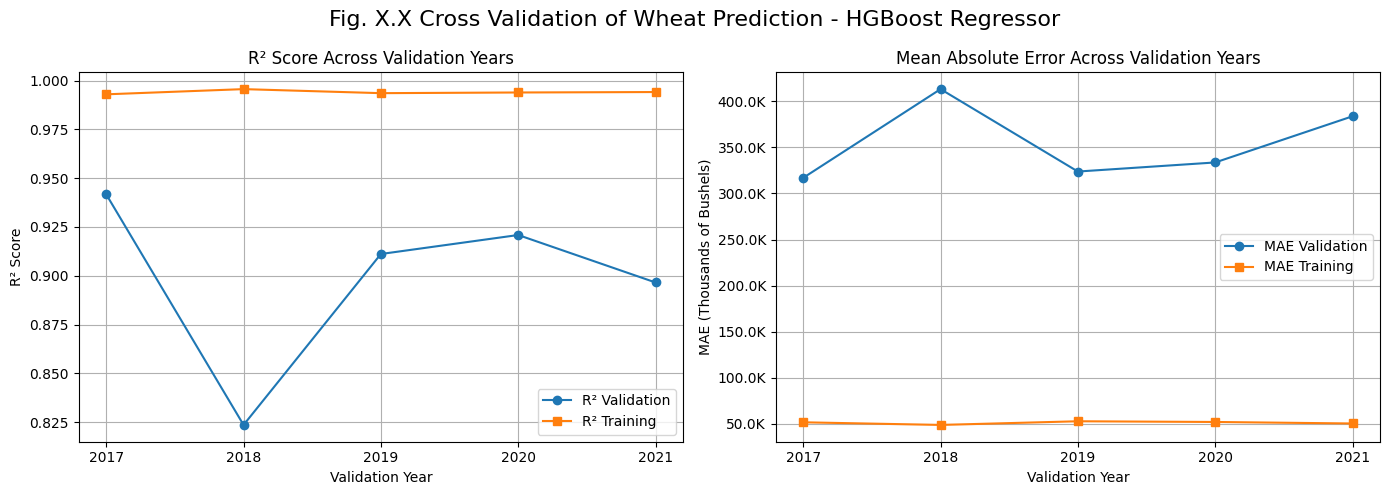

                                      Metric    Train Validation
0                               Avg R2 Score     0.99       0.90
1              Avg Mean Absolute Error (MAE)   51.18K    354.32K
2         Avg Root Mean Squared Error (RMSE)  167.34K    662.42K
3  Avg Mean Absolute Percentage Error (MAPE)    8.24%     39.08%
4                              Avg Max Error    2.06M      4.27M


In [154]:

wheat_cross_val_training_result_complete_features_hgb = helper.perform_cross_validation(train_set=train_set_complete_wheat, 
                                                                 target_column=wheat_target, 
                                                                 scaler=standard_scaler_wheat_complete,
                                                                 model=HistGradientBoostingRegressor(random_state=42, **best_hgb_param_wheat['params']))
helper.plot_cross_validation_result(wheat_cross_val_training_result_complete_features_hgb, title="Fig. X.X Cross Validation of Wheat Prediction - HGBoost Regressor")

#### 4.5.2 Log Transformation + Standard Scaler

In [110]:
hgb_grid_search_results_wheat_log_transformed = []
count = 1
for params in hgb_param_combinations:
    model = HistGradientBoostingRegressor(random_state=42, **params)

    cv_result = helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_wheat_data, 
        wheat_target,
        scaler=standard_scaler_wheat_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=model,
    )

    mean_r2 = np.mean([r['r2_val'] for r in cv_result])
    mean_mae = np.mean([r['mae_val'] for r in cv_result])

    hgb_grid_search_results_wheat_log_transformed.append({
        "params": params,
        "mean_r2": mean_r2,
        "mean_mae": mean_mae
    })
    print(f"\rGrid Search Process: {count}/{len(hgb_param_combinations)}", end='', flush=True)
    count += 1

best_hgb_param_wheat_log_transformed = max(hgb_grid_search_results_wheat_log_transformed, key=lambda x: (x['mean_r2'], -x['mean_mae']))
print()
print("HGBoost Regressor Wheat Prediction Grid Search Result")
print("  Best params:", best_hgb_param_wheat_log_transformed['params'])
print("  Mean R²:", best_hgb_param_wheat_log_transformed['mean_r2'])
print("  Mean MAE:", best_hgb_param_wheat_log_transformed['mean_mae'])

Grid Search Process: 360/360
HGBoost Regressor Wheat Prediction Grid Search Result
  Best params: {'learning_rate': 0.1, 'max_iter': 100, 'max_depth': 5, 'l2_regularization': 5.0, 'min_samples_leaf': 20}
  Mean R²: 0.886561603848277
  Mean MAE: 348109.63599445904


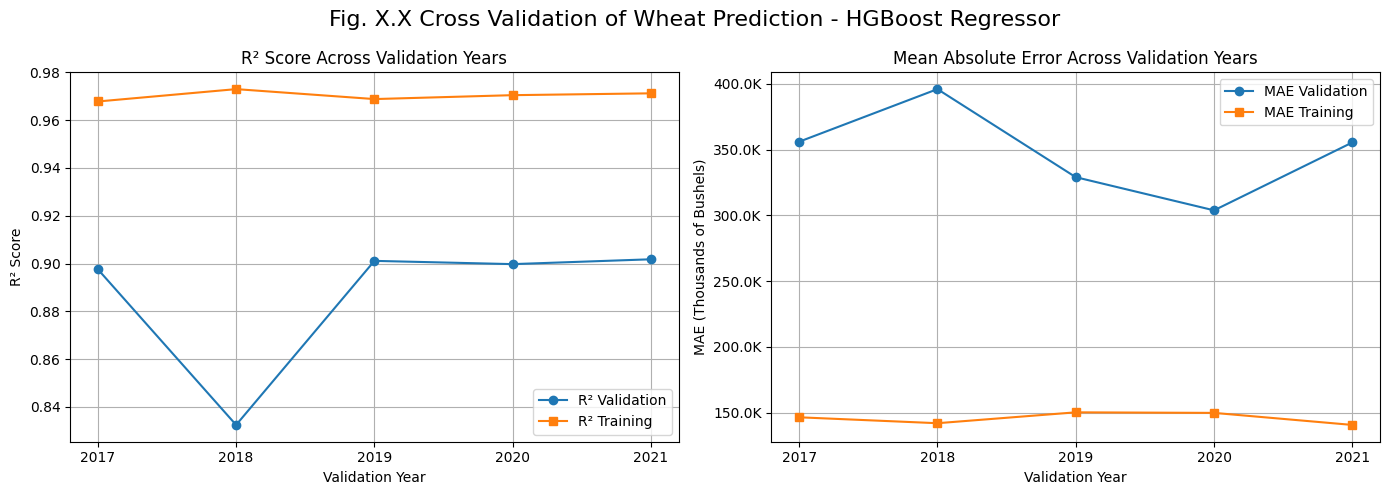

                                      Metric    Train Validation
0                               Avg R2 Score     0.97       0.89
1              Avg Mean Absolute Error (MAE)  145.72K    348.11K
2         Avg Root Mean Squared Error (RMSE)  374.77K    714.55K
3  Avg Mean Absolute Percentage Error (MAPE)   10.80%     25.98%
4                              Avg Max Error    4.74M      5.57M


In [155]:

wheat_cross_val_training_result_complete_features_hgb_log_transformed =  helper.perform_cv_with_precomputed_transforms(
        precomputed_log_transformed_wheat_data, 
        wheat_target,
        scaler=standard_scaler_wheat_complete, 
        verbose=False, 
        max_safe_exp=100,
        model=HistGradientBoostingRegressor(random_state=42, **best_hgb_param_wheat_log_transformed['params'])
)
helper.plot_cross_validation_result(wheat_cross_val_training_result_complete_features_hgb_log_transformed, title="Fig. X.X Cross Validation of Wheat Prediction - HGBoost Regressor")